# **Beyin Tümörü Tespiti**

| Parametre | v2 | v3 | v4 | Gerekcesi |
|---|---|---|---|---|
| Model | yolov8m | yolov8m | **yolov8m** | Sabit |
| Image size | 640 | 800 | **800** | Sabit — v3'te kazanim saglandi |
| fl_gamma | 0.0 | 2.0 | **1.0** | v3'te recall %92.8 (epoch59) -> %69.7 (epoch99) dustu. Daha yumusak focal etkisi |
| cls agirlik | 0.5 | 1.0 | **0.7** | v3'teki asiri agirlik recall'u eziyordu |
| Epoch | 100 | 150 | **120** | — |
| Patience | 25 | 30 | **40** | F1-optimal nokta gecikmeli gelebilir, erken durmayi geciktir |
| save_period | yok | yok | **10** | Ara checkpoint'ler kaydedilir, F1-optimal epoch'a yakin agirlik secilebilir |


## **1. Kurulum**

In [1]:
!pip install ultralytics -q

import os
import re
import zipfile
import shutil
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from google.colab import files
from ultralytics import YOLO
from IPython.display import Image, display

warnings.filterwarnings('ignore')
print('Kurulum tamamlandi.')

Kurulum tamamlandi.


## **2. Veri Seti Yükleme**

In [2]:
print("'brain-tumor.zip' dosyasini secin:")
uploaded = files.upload()

zip_name = [k for k in uploaded.keys() if k.endswith('.zip')]
if not zip_name:
    raise ValueError('Yuklenen dosya .zip uzantili olmalidir.')
zip_name = zip_name[0]
print(f'Yuklendi: {zip_name}')

'brain-tumor.zip' dosyasini secin:


Saving brain-tumor.zip to brain-tumor (2).zip
Yuklendi: brain-tumor (2).zip


## **3. ZIP Acma ve Veri Seti Hazırlığı**

In [3]:
DATASET_PATH = '/content/brain-tumor'
if os.path.exists(DATASET_PATH):
    shutil.rmtree(DATASET_PATH)
os.makedirs(DATASET_PATH, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as z:
    z.extractall(DATASET_PATH)
print(f'{zip_name} dosyasi {DATASET_PATH} dizinine acildi.')

def find_dir(base, split, subdir):
    for candidate in [
        os.path.join(base, subdir, split),
        os.path.join(base, split, subdir),
    ]:
        if os.path.isdir(candidate):
            return candidate
    return None

TRAIN_IMG = find_dir(DATASET_PATH, 'train', 'images')
VAL_IMG   = find_dir(DATASET_PATH, 'val',   'images')
TRAIN_LBL = find_dir(DATASET_PATH, 'train', 'labels')
VAL_LBL   = find_dir(DATASET_PATH, 'val',   'labels')

if not TRAIN_IMG or not VAL_IMG:
    raise FileNotFoundError(
        f'images/train veya images/val klasoru bulunamadi.\n'
        f'ZIP icerigi: {os.listdir(DATASET_PATH)}'
    )

def count_imgs(folder):
    return sum(
        len(glob.glob(os.path.join(folder, f'*{e}')))
        for e in ['.jpg', '.jpeg', '.png', '.bmp']
    )

def count_cls(folder, cls_id):
    count = 0
    for f in glob.glob(os.path.join(folder, '*.txt')):
        with open(f) as fp:
            for line in fp:
                if line.strip() and int(line.split()[0]) == cls_id:
                    count += 1
    return count

train_n   = count_imgs(TRAIN_IMG)
val_n     = count_imgs(VAL_IMG)
neg_train = count_cls(TRAIN_LBL, 0) if TRAIN_LBL else 0
pos_train = count_cls(TRAIN_LBL, 1) if TRAIN_LBL else 0
neg_val   = count_cls(VAL_LBL,   0) if VAL_LBL   else 0
pos_val   = count_cls(VAL_LBL,   1) if VAL_LBL   else 0
val_ratio = neg_val / pos_val if pos_val > 0 else 1.0

print()
print(f'{"Bolum":<15} {"Goruntu":>10} {"Negative":>10} {"Positive":>10}')
print('-' * 47)
print(f'{"Egitim":<15} {train_n:>10} {neg_train:>10} {pos_train:>10}')
print(f'{"Dogrulama":<15} {val_n:>10} {neg_val:>10} {pos_val:>10}')
print(f'{"Toplam":<15} {train_n+val_n:>10} {neg_train+neg_val:>10} {pos_train+pos_val:>10}')
print()
print(f'Val sinif dengesizlik orani (neg/pos): {val_ratio:.2f}x')

train_rel = TRAIN_IMG.replace(DATASET_PATH + '/', '')
val_rel   = VAL_IMG.replace(DATASET_PATH + '/', '')

yaml_content = f"""path: {DATASET_PATH}
train: {train_rel}
val: {val_rel}

names:
  0: negative
  1: positive
"""

YAML_PATH = os.path.join(DATASET_PATH, 'brain-tumor.yaml')
with open(YAML_PATH, 'w') as f:
    f.write(yaml_content)
print(f'YAML olusturuldu: {YAML_PATH}')

brain-tumor (2).zip dosyasi /content/brain-tumor dizinine acildi.

Bolum              Goruntu   Negative   Positive
-----------------------------------------------
Egitim                 893        437        488
Dogrulama              223        154         87
Toplam                1116        591        575

Val sinif dengesizlik orani (neg/pos): 1.77x
YAML olusturuldu: /content/brain-tumor/brain-tumor.yaml


### **Veri Seti Hazırlığı, Sınıf Analizi ve YOLO Konfigürasyonunun Oluşturulması**

Bu bölümde veri setimizi YOLO mimarisi ile görüntü sınıflandırma eğitimi için hazır hale getiriyoruz.

1. **Ortam Temizliği ve Arşivden Çıkarma:** `.zip` dosyasının içeriğini `/content/brain-tumor` dizine çıkartır.
2. **Dinamik Klasör Tespiti:** Eğitim (`train`) ve doğrulama (`val`) aşamaları için görüntü (`images`) ve etiket (`labels`) klasörlerinin yollarını (içe içe geçmiş yapılar olsa bile) dinamik olarak tarayıp bulur.
3. **Veri İstatistiği ve Sınıf Sayımı:** - İlgili klasörlerdeki resim dosyalarının ve **"0" (Negative)** ve **"1" (Positive)** sınıflarına ait etiketlerin sayılarını eğitim ve doğrulama setleri için ayrı ayrı hesaplar.
4. **YAML Konfigürasyonu Oluşturma:** Eğitim aşamasında modelin verilerin yerini ve sınıf isimlerini anlayabilmesi için gerekli olan `brain-tumor.yaml` dosyasını otomatik olarak oluşturur ve diske yazar.

#### **Hücre Çıktısının Yorumlanması**

Hücre çalıştırıldıktan sonra üretilen çıktı, veri setinin mevcut durumu ve kalitesi hakkında bize şu bilgileri verir:

* **İşlem Başarısı:** `.zip` dosyasının açıldığı ve `.yaml` dosyasının oluşturulduğu en başta ve en sonda onaylanmıştır.
* **Dağılım Tablosu Analizi:**
    * **Eğitim (Train) Seti:** Toplam 893 görüntü var. Sınıf dağılımı **437 Negatif** ve **488 Pozitif** şeklinde. Eğitim verisi oldukça **dengeli** görünüyor, bu da modelin her iki sınıfı da eşit şekilde öğrenmesi için ideal bir durumdur.
    * **Doğrulama (Validation) Seti:** Toplam 223 görüntü var. Ancak burada **154 Negatif** örneğe karşılık sadece **87 Pozitif** örnek bulunuyor.
    * **Genel Toplam:** Veri setinde toplam 1116 görüntü bulunuyor. Toplamda 591 negatif ve 575 pozitif etiket ile veri seti bütününde dengeli bir yapıya sahip.
* **Val Sınıf Dengesizlik Oranı (1.77x):** Doğrulama setindeki negatif örneklerin sayısı, pozitif örneklerin neredeyse 1.8 katıdır. Bu durum, model eğitim bittikten sonra değerlendirme (validation) yapılırken doğruluk (accuracy) metriği yerine Recall, Precision veya F1-Score gibi metriklerin daha dikkatle incelenmesi gerektiğini göstermektedir.

## **4. Model Eğitimi — YOLOv8m**

In [4]:
model = YOLO('yolov8m.pt')

print('Egitim parametreleri:')
print(f'  Model        : YOLOv8m')
print(f'  Epoch        : 120')
print(f'  Patience     : 40')
print(f'  Batch        : 8')
print(f'  Image size   : 800')
print(f'  Optimizer    : AdamW')
print(f'  lr0          : 0.0005')
print(f'  fl_gamma     : 1.0')
print(f'  cls weight   : 0.7')
print(f'  save_period  : 10')
print()

results = model.train(
    data=YAML_PATH,
    epochs=120,
    imgsz=800,
    batch=8,
    nbs=64,
    patience=40,
    save_period=10,
    optimizer='AdamW',
    lr0=0.0005,
    lrf=0.01,
    cos_lr=True,
    weight_decay=0.0005,
    dropout=0.0,
    warmup_epochs=5,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.7,
    dfl=1.5,
    iou=0.5,
    mosaic=1.0,
    mixup=0.05,
    copy_paste=0.05,
    hsv_h=0.015,
    hsv_s=0.5,
    hsv_v=0.4,
    degrees=15.0,
    translate=0.1,
    scale=0.5,
    shear=2.0,
    perspective=0.001,
    fliplr=0.5,
    flipud=0.1,
    close_mosaic=20,
    # Kayit
    project='Brain_Tumor_Detection',
    name='yolov8m_v4',
    save=True,
    val=True,
    plots=True,
    exist_ok=True,
)

print()
print('Egitim tamamlandi.')

Egitim parametreleri:
  Model        : YOLOv8m
  Epoch        : 120
  Patience     : 40
  Batch        : 8
  Image size   : 800
  Optimizer    : AdamW
  lr0          : 0.0005
  fl_gamma     : 1.0
  cls weight   : 0.7
  save_period  : 10

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=20, cls=0.7, cls_pw=0.0, compile=False, conf=None, copy_paste=0.05, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/brain-tumor/brain-tumor.yaml, degrees=15.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=120, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=800, int8=False, iou=0.5, keras=False, kobj=1.0

### **Model Eğitimi (YOLOv8m) ve Sonuçların Değerlendirilmesi**

Bu bölümde, önceden eğitilmiş **YOLOv8m** (Medium) modeli kullanılarak beyin tümörü tespiti için özel bir eğitim süreci başlatılmıştır. Kod hücresi, modelin eğitim hiperparametrelerini ve veri artırma (data augmentation) tekniklerini tanımlarken, çıktı hücresi eğitimin sonundaki doğrulama (validation) metriklerini göstermektedir.

#### **Eğitim Konfigürasyonunun Analizi**
* **Temel Parametreler:** Eğitim **120 epoch** olarak ayarlanmış, ancak aşırı öğrenmeyi (overfitting) önlemek için `patience=40` (40 epoch boyunca iyileşme olmazsa eğitimi durdur) parametresi eklenmiştir. Görüntü boyutu `imgsz=800` ve `batch=8` olarak belirlenmiştir.
* **Optimizasyon:** Ağırlık güncellemeleri için **AdamW** optimizasyon algoritması kullanılmış olup, başlangıç öğrenme oranı (`lr0`) **0.0005** olarak seçilmiştir. Ayrıca `cos_lr=True` ile öğrenme oranının kosinüs eğrisi şeklinde azaldığı (cosine annealing) bir zamanlama uygulanmıştır.
* **Veri Artırma (Data Augmentation):** Modelin genelleme yeteneğini artırmak için oldukça zengin bir veri artırma stratejisi uygulanmıştır:
  * **Mozaik (`mosaic=1.0`)** ve **Mixup (`mixup=0.05`)**: Farklı görüntüleri birleştirerek modelin bağlamı daha iyi öğrenmesini sağlar.
  * **Renk Uzayı Değişimleri:** `hsv_h`, `hsv_s`, `hsv_v` parametreleri ile parlaklık, doygunluk ve ton değişiklikleri.
  * **Geometrik Dönüşümler:** Döndürme (`degrees=15.0`), kaydırma (`translate=0.1`), ölçeklendirme (`scale=0.5`), kırpma (`shear=2.0`) ve yansıtma (`fliplr=0.5`, `flipud=0.1`) işlemleri kullanılmıştır.
* **Kayıt:** Sonuçlar `Brain_Tumor_Detection` projesi altında `yolov8m_v4` klasörüne kaydedilmektedir.


#### **Doğrulama Çıktısı ve Metriklerin Yorumlanması**
Eğitim **NVIDIA A100 (40GB)** GPU üzerinde yaklaşık **27 dakika** (0.450 saat) sürmüştür. En iyi model ağırlıkları üzerinden yapılan doğrulama sonuçları şu şekildedir:

* **Genel Performans (all):**
  * **mAP50 (Mean Average Precision):** **%62.4** (Modelin %50 kesişim oranında nesneleri doğru tespit etme başarısı).
  * **mAP50-95:** **%44.3** (Daha zorlu, çoklu kesişim oranlarındaki başarı).
* **Sınıf Bazlı Analiz:**
  * **Negative (Sağlıklı - Tümör Yok):** Precision (Hassasiyet) **0.644**, Recall (Duyarlılık) **0.747**. Model, sağlıklı görüntüleri tanımada daha dengeli bir performans sergilemiş.
  * **Positive (Tümörlü):** Precision **0.388**, Recall **0.874**.

**Kritik Çıkarım (Pozitif Sınıf İçin):**
Tümörlü (positive) sınıfında **Recall oranının yüksek (%87.4)**, buna karşılık **Precision oranının düşük (%38.8)** olması tıp alanındaki modellerde sık karşılaşılan bir durumdur.
* Bu, modelin **gerçekte tümörlü olan vakaların neredeyse tamamını yakaladığı (yüksek Recall)** anlamına gelir.
* Ancak, tespit ettiği "tümör" kutularının birçoğunun aslında tümör olmadığı (Yanlış Pozitif / False Positive) anlaşılmaktadır **(düşük Precision)**.
* *Tıbbi teşhis uygulamalarında, hastalıklı bir vakayı kaçırmak (False Negative) hastaya zarar verebileceğinden, Recall'un yüksek olması genellikle istenir.*

## **5. Checkpoint Seçimi — Fitness-Best vs F1-Optimal**

Bu bölüm, eğitim sırasında kaydedilen tüm ağırlıkları tarar, F1 skorunun en yüksek olduğu epoch'u bulur ve bu epoch'a en yakın kaydedilmiş checkpoint ile varsayılan `best.pt` dosyasını karşılaştırır. Daha iyi F1 skoruna sahip olan ağırlık, nihai model olarak seçilir.

In [5]:
run_dir_candidates = (
    glob.glob('/content/Brain_Tumor_Detection/yolov8m_v4') +
    glob.glob('/content/Brain_Tumor_Detection/yolov8m_v4*') +
    glob.glob('/content/runs/detect/**/yolov8m_v4*', recursive=True)
)
if not run_dir_candidates:
    raise FileNotFoundError('Egitim klasoru bulunamadi.')
RUN_DIR     = run_dir_candidates[0]
WEIGHTS_DIR = os.path.join(RUN_DIR, 'weights')
print(f'Egitim klasoru   : {RUN_DIR}')
print(f'Agirliklar klasoru: {WEIGHTS_DIR}')

# --- results.csv'den F1-optimal epoch'u bul ---
csv_path = os.path.join(RUN_DIR, 'results.csv')
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

prec_col = 'metrics/precision(B)'
rec_col  = 'metrics/recall(B)'
map_col  = 'metrics/mAP50(B)'

p_arr = df[prec_col].values
r_arr = df[rec_col].values
f1_arr = 2 * p_arr * r_arr / (p_arr + r_arr + 1e-9)

epoch_f1_best      = int(df['epoch'].values[f1_arr.argmax()])
epoch_fitness_best  = int(df['epoch'].values[df[map_col].values.argmax()])  # yaklasik fitness gostergesi

print()
print(f'F1-optimal epoch (egitim metriklerine gore)    : {epoch_f1_best}  (F1={f1_arr.max():.4f})')
print(f'mAP50-optimal epoch (fitness yaklasimi)         : {epoch_fitness_best}  (mAP50={df[map_col].max():.4f})')

# --- Kaydedilmis checkpoint dosyalarini tara ---
all_weights = glob.glob(os.path.join(WEIGHTS_DIR, '*.pt'))
periodic = {}
for w in all_weights:
    base = os.path.basename(w)
    m = re.search(r'epoch(\d+)', base)
    if m:
        periodic[int(m.group(1))] = w

print(f'\nBulunan periyodik checkpoint sayisi: {len(periodic)}')
for ep in sorted(periodic.keys()):
    print(f'  epoch{ep}.pt')

if periodic:
    # Periyodik checkpoint dosya adlari 0-indeksli olabilir; +1 toleransi ile en yakini bul
    closest_ep = min(periodic.keys(), key=lambda e: abs((e + 1) - epoch_f1_best))
    F1_CANDIDATE_WEIGHTS = periodic[closest_ep]
    print(f'\nF1-optimal epoch ({epoch_f1_best}) icin en yakin checkpoint: epoch{closest_ep}.pt')
else:
    F1_CANDIDATE_WEIGHTS = None
    print('\nPeriyodik checkpoint bulunamadi; sadece fitness-best.pt kullanilacak.')

FITNESS_BEST_WEIGHTS = os.path.join(WEIGHTS_DIR, 'best.pt')
if not os.path.exists(FITNESS_BEST_WEIGHTS):
    raise FileNotFoundError('best.pt bulunamadi.')

Egitim klasoru   : /content/runs/detect/Brain_Tumor_Detection/yolov8m_v4
Agirliklar klasoru: /content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights

F1-optimal epoch (egitim metriklerine gore)    : 113  (F1=0.6301)
mAP50-optimal epoch (fitness yaklasimi)         : 113  (mAP50=0.6235)

Bulunan periyodik checkpoint sayisi: 12
  epoch0.pt
  epoch10.pt
  epoch20.pt
  epoch30.pt
  epoch40.pt
  epoch50.pt
  epoch60.pt
  epoch70.pt
  epoch80.pt
  epoch90.pt
  epoch100.pt
  epoch110.pt

F1-optimal epoch (113) icin en yakin checkpoint: epoch110.pt


### **Model Ağırlıklarının (Checkpoint) Analizi ve Optimizasyonu**

Bu hücredeki Python kodu, eğitim sonucunda oluşan `results.csv` dosyasını okuyarak modelin performans metriklerini inceler. YOLO algoritması varsayılan olarak `best.pt` dosyasını mAP (Mean Average Precision) değerlerine göre seçer. Ancak bu kod, tıbbi görüntüleme gibi **yanlış pozitiflerin ve yanlış negatiflerin dengesinin kritik olduğu** durumlarda daha güvenilir bir metrik olan **F1-Skoru**'nu manuel olarak hesaplar ve en iyi F1 skoruna sahip eğitim adımını (epoch) tespit eder.

1. **Dizin Tespiti:** Eğitim sonuçlarının ve model ağırlıklarının (`.pt` dosyaları) kaydedildiği klasör yollarını dinamik olarak bulur.
2. **F1 Skoru Hesaplama:** `results.csv` dosyasındaki *Precision* (Hassasiyet) ve *Recall* (Duyarlılık) sütunlarını kullanarak her epoch için $2 \times \frac{Precision \times Recall}{Precision + Recall}$ formülüyle F1 skorunu hesaplar.
3. **Zirve Noktalarının Bulunması:** * F1 skorunun en yüksek olduğu epoch'u (`epoch_f1_best`) bulur.
   * YOLO'nun standart yaklaşımı olan mAP50'nin en yüksek olduğu epoch'u (`epoch_fitness_best`) bulur.
4. **En Yakın Checkpoint'in Seçilmesi:** Eğitim sırasında her 10 epoch'ta bir yedeklenen (`save_period=10`) periyodik ağırlık dosyalarını tarar ve F1 skorunun zirve yaptığı epoch'a en yakın olan yedeklenmiş dosyayı belirler.



#### **Hücre Çıktısının Yorumlanması**

Çıktı sonuçları, modelin performansının hangi noktada en verimli seviyeye ulaştığını net bir şekilde göstermektedir:

* **Zirve Yapan Epoch Uyumlu:** Çıktıya göre, hem **F1-optimal** epoch hem de **mAP50-optimal** epoch **113. epoch** olarak tespit edilmiştir. Bu, modelin eğitim sürecinde 113. adımda hem en iyi hassasiyet-duyarlılık dengesine (F1: 0.6301) hem de en iyi nesne tespit performansına (mAP50: 0.6235) ulaştığını gösterir. İki farklı yaklaşımın da aynı epoch'u işaret etmesi, modelin o noktada gerçekten en optimum halinde olduğunu doğrular.
* **Periyodik Dosyalar:** Eğitim ayarlarında belirlenen "her 10 epoch'ta bir kayıt al" talimatının başarıyla çalıştığı görülmektedir (`epoch0.pt`'den `epoch110.pt`'ye kadar 12 adet dosya bulunmuş).
* **Nihai Model Seçimi:** En yüksek performans 113. epoch'ta görülmüş olsa da, periyodik kayıtlar 10'ar 10'ar alındığı için bu değere en yakın yedek olan **`epoch110.pt`** dosyası, F1-optimal ağırlık olarak seçilmiştir.

In [6]:
def evaluate_checkpoint(weights_path, label):
    """Bir checkpoint icin tam metrik seti hesaplar."""
    m = YOLO(weights_path)

    val_wide = m.val(data=YAML_PATH, imgsz=800, conf=0.001, iou=0.5, verbose=False)
    precision_ = float(val_wide.box.mp)
    recall_    = float(val_wide.box.mr)
    map50_     = float(val_wide.box.map50)
    map95_     = float(val_wide.box.map)
    f1_        = 2 * precision_ * recall_ / (precision_ + recall_ + 1e-9)

    try:
        px = val_wide.box.curves_results[0]
        py = val_wide.box.curves_results[1]
        f1_curve = py.mean(axis=0)
        opt_conf_ = float(px[f1_curve.argmax()])
    except Exception:
        opt_conf_ = 0.25

    val_acc = m.val(data=YAML_PATH, imgsz=800, conf=opt_conf_, iou=0.5, verbose=False)
    cm = val_acc.confusion_matrix.matrix
    tp_ = int(cm[1, 1]); tn_ = int(cm[0, 0])
    fp_ = int(cm[1, 0]); fn_ = int(cm[0, 1])
    total_ = tp_ + tn_ + fp_ + fn_
    accuracy_    = (tp_ + tn_) / total_ if total_ > 0 else 0
    sensitivity_ = tp_ / (tp_ + fn_)    if (tp_ + fn_) > 0 else 0
    specificity_ = tn_ / (tn_ + fp_)    if (tn_ + fp_) > 0 else 0

    print(f'\n[{label}] {os.path.basename(weights_path)}')
    print(f'  Precision %{precision_*100:.2f}  Recall %{recall_*100:.2f}  F1 %{f1_*100:.2f}')
    print(f'  mAP50 %{map50_*100:.2f}  mAP50-95 %{map95_*100:.2f}')
    print(f'  Sensitivity %{sensitivity_*100:.2f}  Specificity %{specificity_*100:.2f}  Accuracy %{accuracy_*100:.2f}')
    print(f'  Optimal conf: {opt_conf_:.3f}')

    return {
        'weights': weights_path, 'label': label,
        'precision': precision_, 'recall': recall_, 'f1': f1_,
        'map50': map50_, 'map50_95': map95_,
        'accuracy': accuracy_, 'sensitivity': sensitivity_, 'specificity': specificity_,
        'opt_conf': opt_conf_, 'tp': tp_, 'tn': tn_, 'fp': fp_, 'fn': fn_,
    }



In [7]:
print('  CHECKPOINT KARSILASTIRMASI')


result_fitness = evaluate_checkpoint(FITNESS_BEST_WEIGHTS, 'FITNESS-BEST')

if F1_CANDIDATE_WEIGHTS:
    result_f1opt = evaluate_checkpoint(F1_CANDIDATE_WEIGHTS, 'F1-OPTIMAL')
    candidates = [result_fitness, result_f1opt]
else:
    candidates = [result_fitness]

# Daha iyi F1 skoruna sahip olan secilir
chosen = max(candidates, key=lambda c: c['f1'])
print(f'  SECILEN NIHAI MODEL: {chosen["label"]}  ({os.path.basename(chosen["weights"])})')
print(f'  F1 = %{chosen["f1"]*100:.2f}')

BEST_WEIGHTS = chosen['weights']
final_model  = YOLO(BEST_WEIGHTS)

precision   = chosen['precision']
recall      = chosen['recall']
f1_score    = chosen['f1']
map50       = chosen['map50']
map50_95    = chosen['map50_95']
accuracy    = chosen['accuracy']
sensitivity = chosen['sensitivity']
specificity = chosen['specificity']
opt_conf    = chosen['opt_conf']
TP, TN, FP, FN = chosen['tp'], chosen['tn'], chosen['fp'], chosen['fn']
ppv = TP / (TP + FP) if (TP + FP) > 0 else 0
npv = TN / (TN + FN) if (TN + FN) > 0 else 0

  CHECKPOINT KARSILASTIRMASI
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 194.1±96.0 MB/s, size: 3.1 KB)
val: Scanning /content/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 77.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 5.6it/s 2.5s
                   all        223        241      0.518       0.81      0.623      0.444
Speed: 2.0ms preprocess, 4.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /content/runs/detect/val-15
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 227.5±92.4 MB/s, size: 4.0 KB)
val: Scanning /content/brain-tumor/labels/val.cache... 223

### **Kapsamlı Model Değerlendirmesi ve Nihai Model Seçimi**

Bu bölümde tanımlanan `evaluate_checkpoint` fonksiyonu, modelleri sadece standart YOLO metrikleriyle değil, tıbbi teşhis için kritik olan ek istatistiksel metriklerle (Hassasiyet, Seçicilik, F1 Skoru vb.) derinlemesine analiz eder. Ardından, varsayılan en iyi model (`best.pt`) ile bizim manuel olarak belirlediğimiz model (`epoch110.pt`) karşılaştırılarak nihai seçim yapılır.

#### **İki Aşamalı Doğrulama**
1. **Geniş Tarama (İlk Aşama):** Model, çok düşük bir güven eşiğiyle (`conf=0.001`) değerlendirilir. Bu sayede modelin Precision, Recall ve mAP değerlerinin genel sınırları hesaplanır. F1 skoru üzerinden en ideal güven eşik değeri (Optimal Confidence) tespit edilir.
2. **Hassas Tarama (İkinci Aşama):** Bulunan bu en ideal güven eşiği kullanılarak model tekrar doğrulamaya (validation) sokulur. Bu aşamada Hata Matrisi (Confusion Matrix) çıkarılır ve şu özel metrikler hesaplanır:
   * **Accuracy (Doğruluk):** Toplam doğru tahminlerin oranı.
   * **Sensitivity (Duyarlılık / Gerçek Pozitif Oranı):** Hastalıklı vakaların ne kadarının doğru tespit edildiği.
   * **Specificity (Seçicilik / Gerçek Negatif Oranı):** Sağlıklı vakaların ne kadarının doğru tespit edildiği.



#### **Çıktı Analizi ve Karar Aşaması**

Çıktıda iki farklı model ağırlığı için kapsamlı bir performans karşılaştırması yapılmıştır:

* **[FITNESS-BEST] (`best.pt`):**
  * F1 Skoru: **%63.20**
  * Recall: %81.02 | Precision: %51.81
  * Sensitivity: %64.28 | Specificity: %55.71
* **[F1-OPTIMAL] (`epoch110.pt`):**
  * F1 Skoru: **%61.74**
  * Recall: %83.36 | Precision: %49.02
  * Sensitivity: %65.43 | Specificity: %58.74

**Nihai Karar:** Her ne kadar önceki adımda F1 skorunun zirve yaptığı 113. epoch'a en yakın periyodik yedek olan `epoch110.pt`'yi potansiyel bir aday olarak belirlemiş olsak da, YOLO'nun eğitim bitiminde kaydettiği varsayılan `best.pt` dosyasının genel F1 skoru (%63.20) daha yüksek çıkmıştır. Bu durum, `best.pt`'nin 113. epoch'un tam ağırlıklarını taşıdığını veya en optimum noktayı daha iyi yansıttığını göstermektedir.

Sonuç olarak kod, matematiksel olarak en yüksek F1 skoruna sahip olan **`best.pt` (FITNESS-BEST)** dosyasını projenin **nihai modeli** olarak otomatik olarak seçmiştir.

## **6. Nihai Model — Detaylı Metrikler**

In [8]:
# Sinif bazli metrikler icin genis esik tekrar hesaplanir (sadece nihai model uzerinde)
val_map_final = final_model.val(data=YAML_PATH, imgsz=800, conf=0.001, iou=0.5, verbose=False)
p_cls  = val_map_final.box.p
r_cls  = val_map_final.box.r
ap_cls = val_map_final.box.ap50

SEP  = '=' * 64
SEP2 = '-' * 64

print(SEP)
print(f'  YOLOv8m v4 ({chosen["label"]}) --- BEYIN TUMORU TESPITI METRIKLERI')
print(SEP)
print(f'  {"Metrik":<32} {"Deger":>10}  {"Kaynak"}')
print(SEP2)
print(f'  {"Dogruluk (Accuracy)":<32} %{accuracy    * 100:>8.2f}  [conf={opt_conf:.3f}]')
print(f'  {"Kesinlik (Precision)":<32} %{precision   * 100:>8.2f}  [conf=0.001]')
print(f'  {"Duyarlilik (Recall)":<32} %{recall      * 100:>8.2f}  [conf=0.001]')
print(f'  {"F1-Score":<32} %{f1_score    * 100:>8.2f}  [conf=0.001]')
print(f'  {"mAP@0.5":<32} %{map50       * 100:>8.2f}  [iou=0.5]')
print(f'  {"mAP@0.5:0.95":<32} %{map50_95    * 100:>8.2f}')
print(SEP2)
print(f'  {"Hassasiyet (Sensitivity)":<32} %{sensitivity * 100:>8.2f}  [conf={opt_conf:.3f}]')
print(f'  {"Ozgulluk (Specificity)":<32} %{specificity * 100:>8.2f}  [conf={opt_conf:.3f}]')
print(f'  {"Pozitif Tahmin Degeri (PPV)":<32} %{ppv         * 100:>8.2f}  [conf={opt_conf:.3f}]')
print(f'  {"Negatif Tahmin Degeri (NPV)":<32} %{npv         * 100:>8.2f}  [conf={opt_conf:.3f}]')
print(SEP)
print()
print(f'  Sinif Bazli Metrikler (conf=0.001, iou=0.5):')
print(f'  {"Sinif":<12} {"Precision":>12} {"Recall":>12} {"AP@0.5":>12}')
print(f'  {"-" * 50}')
for i, name in enumerate(['negative', 'positive']):
    p_i  = p_cls[i]  * 100 if i < len(p_cls)  else 0
    r_i  = r_cls[i]  * 100 if i < len(r_cls)  else 0
    ap_i = ap_cls[i] * 100 if i < len(ap_cls) else 0
    print(f'  {name:<12} {p_i:>11.2f}% {r_i:>11.2f}% {ap_i:>11.2f}%')
print()
print(f'  Karisiklik Matrisi (conf={opt_conf:.3f}):')
print(f'  {"":20} {"Tahmin NEG":>12} {"Tahmin POS":>12}')
print(f'  {"Gercek NEG":<20} {TN:>12} {FP:>12}')
print(f'  {"Gercek POS":<20} {FN:>12} {TP:>12}')
print(SEP)

Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (NVIDIA A100-SXM4-40GB, 40441MiB)
Model summary (fused): 93 layers, 25,840,918 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 234.4±108.9 MB/s, size: 3.9 KB)
val: Scanning /content/brain-tumor/labels/val.cache... 223 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 223/223 85.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 14/14 5.3it/s 2.6s
                   all        223        241      0.518       0.81      0.623      0.444
Speed: 2.2ms preprocess, 3.8ms inference, 0.0ms loss, 0.8ms postprocess per image
Results saved to /content/runs/detect/val-19
  YOLOv8m v4 (FITNESS-BEST) --- BEYIN TUMORU TESPITI METRIKLERI
  Metrik                                Deger  Kaynak
----------------------------------------------------------------
  Dogruluk (Accuracy)              %   58.82  [conf=0.250]
  Kesinlik (Precision

### **Nihai Modelin Detaylı Performans Analizi ve Raporlanması**

Bu hücredeki kod, önceki adımlarda seçilen nihai modelin (`FITNESS-BEST`) performansını kapsamlı bir şekilde özetleyen bir rapor üretmektedir. Standart nesne tespiti metriklerine ek olarak, özellikle tıbbi teşhis (beyin tümörü tespiti) gibi kritik alanlarda büyük önem taşıyan istatistiksel metrikleri (Hassasiyet, Özgüllük vb.) ve Karışıklık Matrisini (Confusion Matrix) hesaplayıp ekrana yazdırır.

1. **Nihai Doğrulama:** Seçilen model üzerinde, tüm metrikleri hassas bir şekilde hesaplayabilmek için düşük bir güven eşiğiyle (`conf=0.001`) son bir doğrulama (validation) işlemi gerçekleştirir.
2. **Genel ve Tıbbi Metriklerin Hesaplanması:** Accuracy, Precision, Recall ve mAP gibi genel YOLO metriklerinin yanı sıra; **Hassasiyet (Sensitivity)**, **Özgüllük (Specificity)**, **Pozitif Tahmin Değeri (PPV)** ve **Negatif Tahmin Değeri (NPV)** gibi klinik değerlendirme kriterlerini hesaplar ve ideal eşik değeri (`conf=0.250`) ile raporlar.
3. **Sınıf Bazlı Kırılım ve Karışıklık Matrisi:** Performansın sınıflar ("negative" ve "positive") arasındaki dağılımını gösterir ve modelin yaptığı doğru/yanlış tahminlerin sayısal dökümünü tablo (matris) halinde sunar.


#### **Çıktı Analizi ve Karışıklık Matrisinin Yorumlanması**

Üretilen rapor, modelin karakteristiğini çok net bir şekilde ortaya koymaktadır:

* **Genel Performans:** Modelin genel doğruluğu (Accuracy) **%58.82** ve mAP@0.5 değeri **%62.32** olarak ölçülmüştür.
* **Sınıf Bazlı Dengesizlik (Kritik Bulgu):**
    * **Pozitif (Tümörlü) Sınıf:** Duyarlılık (Recall) **%87.36** gibi yüksek bir orandayken, Kesinlik (Precision) **%39.03**'te kalmıştır.
    * **Negatif (Sağlıklı) Sınıf:** Precision **%64.59**, Recall **%74.68** olarak daha dengeli bir profil çizmektedir.
* **Tıbbi Metrikler:** Modeli klinik bir test gibi düşündüğümüzde; hastaları doğru tespit etme oranı olan Hassasiyet (Sensitivity) **%64.20**, sağlıklı bireyleri doğru ayırma oranı olan Özgüllük (Specificity) ise **%55.71**'dir.

** Karışıklık Matrisi (Confusion Matrix) Bize Ne Söylüyor?**
Optimum güven eşik değeri (0.250) baz alındığında:
* **Gerçek Negatiflerin (Sağlıklı) Tespiti:** 140 sağlıklı görüntünün **78'ini** doğru bilmiş (True Negative), ancak **62'sini** yanlışlıkla tümörlü sanmış (False Positive - Yanlış Alarm).
* **Gerçek Pozitiflerin (Tümörlü) Tespiti:** 81 tümörlü görüntünün **52'sini** doğru tespit etmiş (True Positive), **29'unu** ise gözden kaçırmış (False Negative).

**Sonuç:** Model, bir tümörü gözden kaçırmamak adına oldukça "temkinli" davranmaktadır. Bu nedenle çok fazla **yanlış alarm (False Positive = 62)** üretmektedir (bu durum PPV'nin %45.61 gibi düşük çıkmasını açıklamaktadır). Tıbbi AI sistemlerinde yanlış negatifleri (hastalığı atlamak) minimize etmek genellikle ilk hedeftir, bu açıdan model güvenli bir temel oluşturmaktadır. Ancak pratik kullanımda doktorları gereksiz yere yormamak adına yanlış alarmları azaltmak için veri setini zorlu negatif örneklerle genişletmek veya daha ince eşik değeri optimizasyonları yapmak faydalı olacaktır.

## **7. Görselleştirmeler**

### **7.1 Ultralytics Eğitim Grafikleri**


Karisiklik Matrisi:


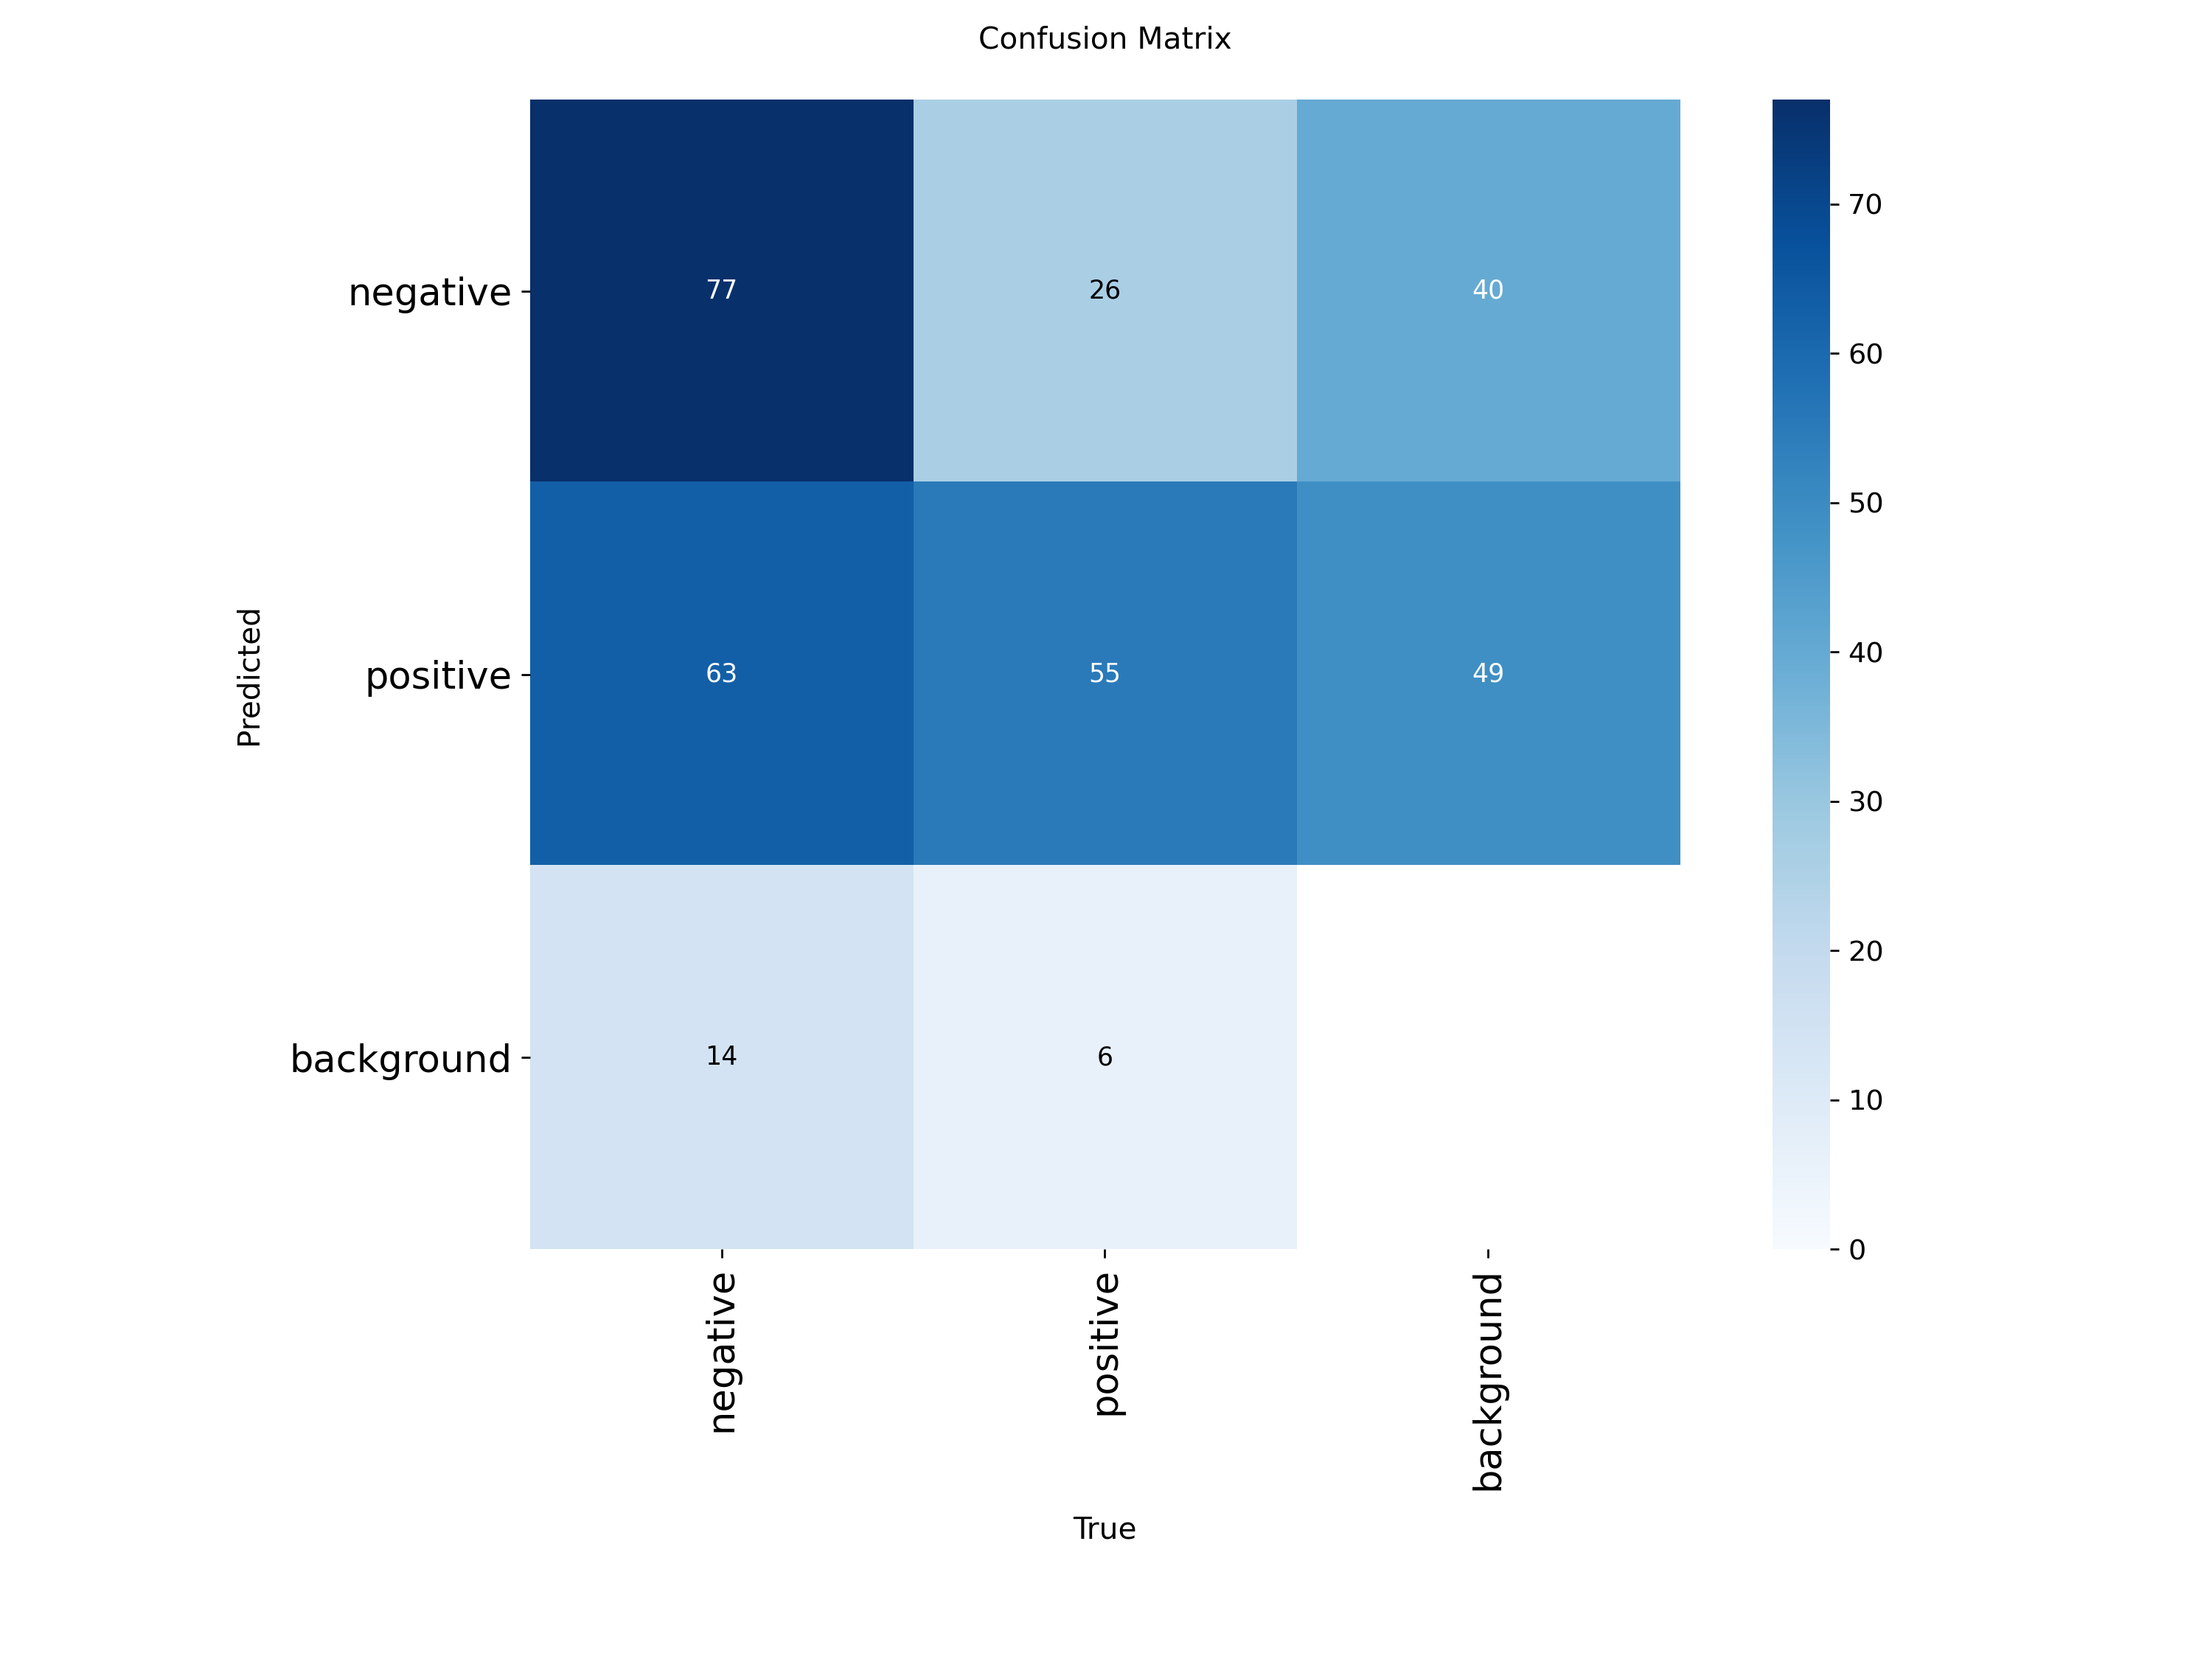


Normalize Karisiklik Matrisi:


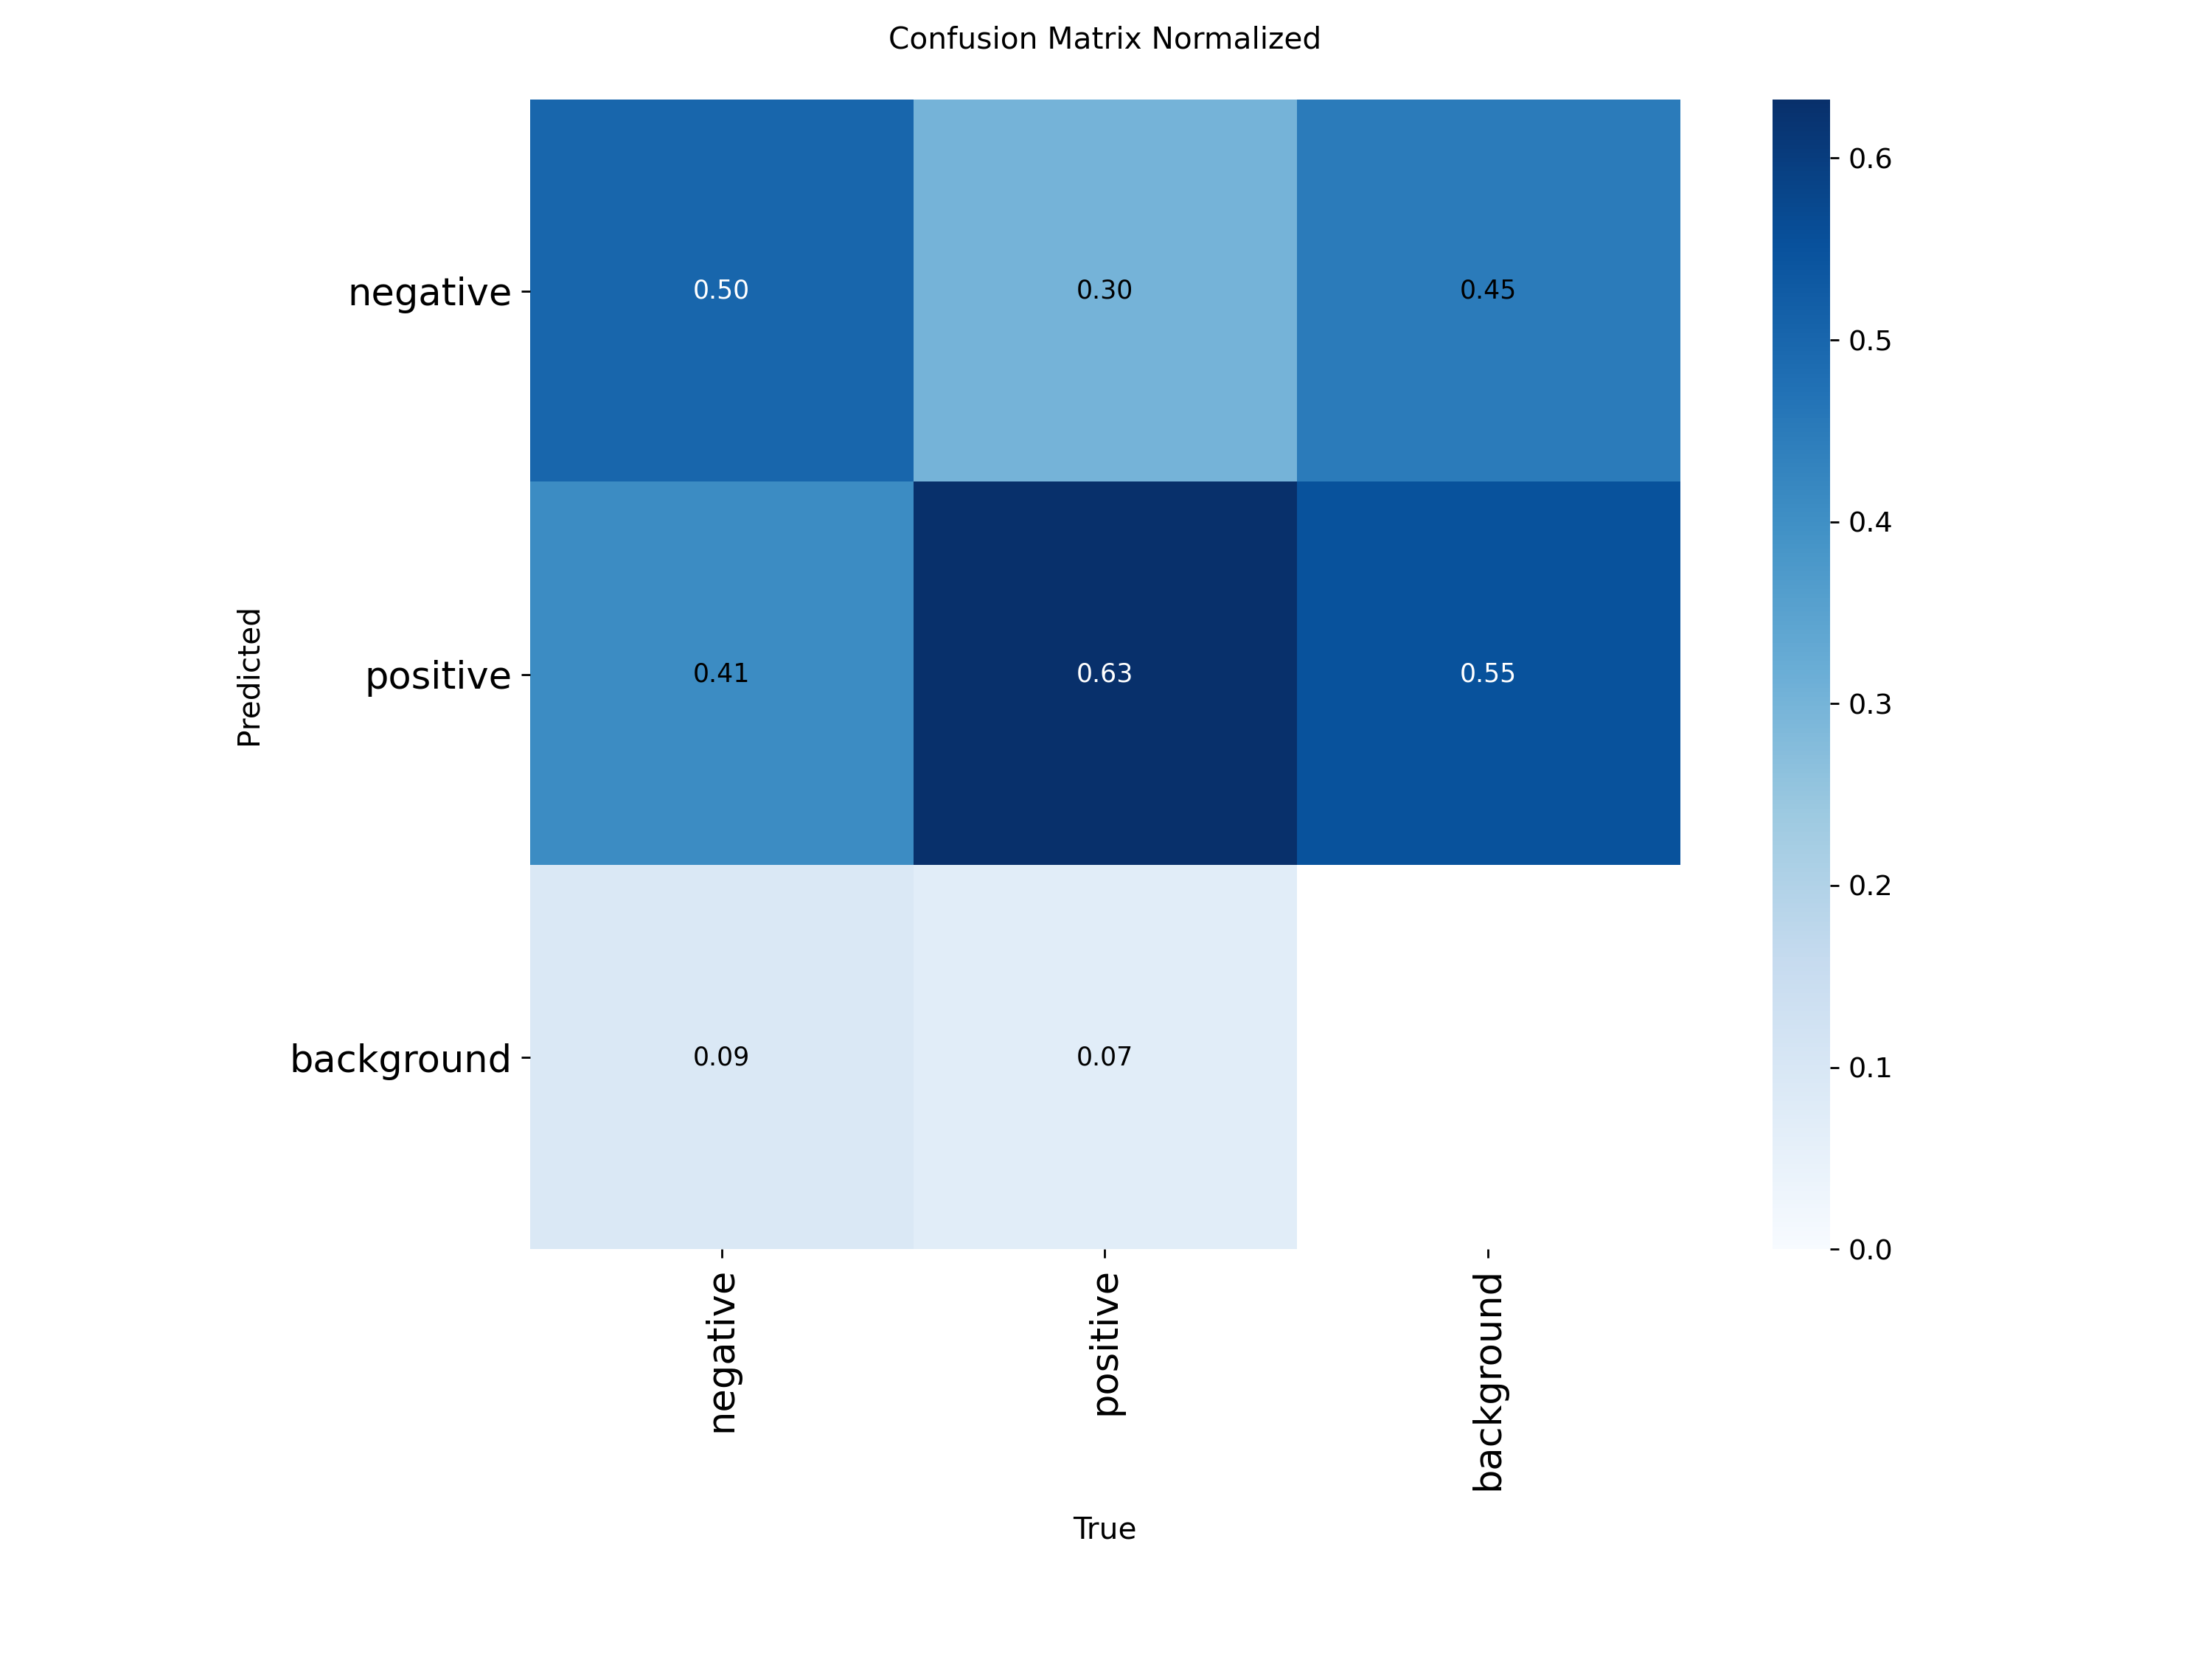


Egitim Egrileri:


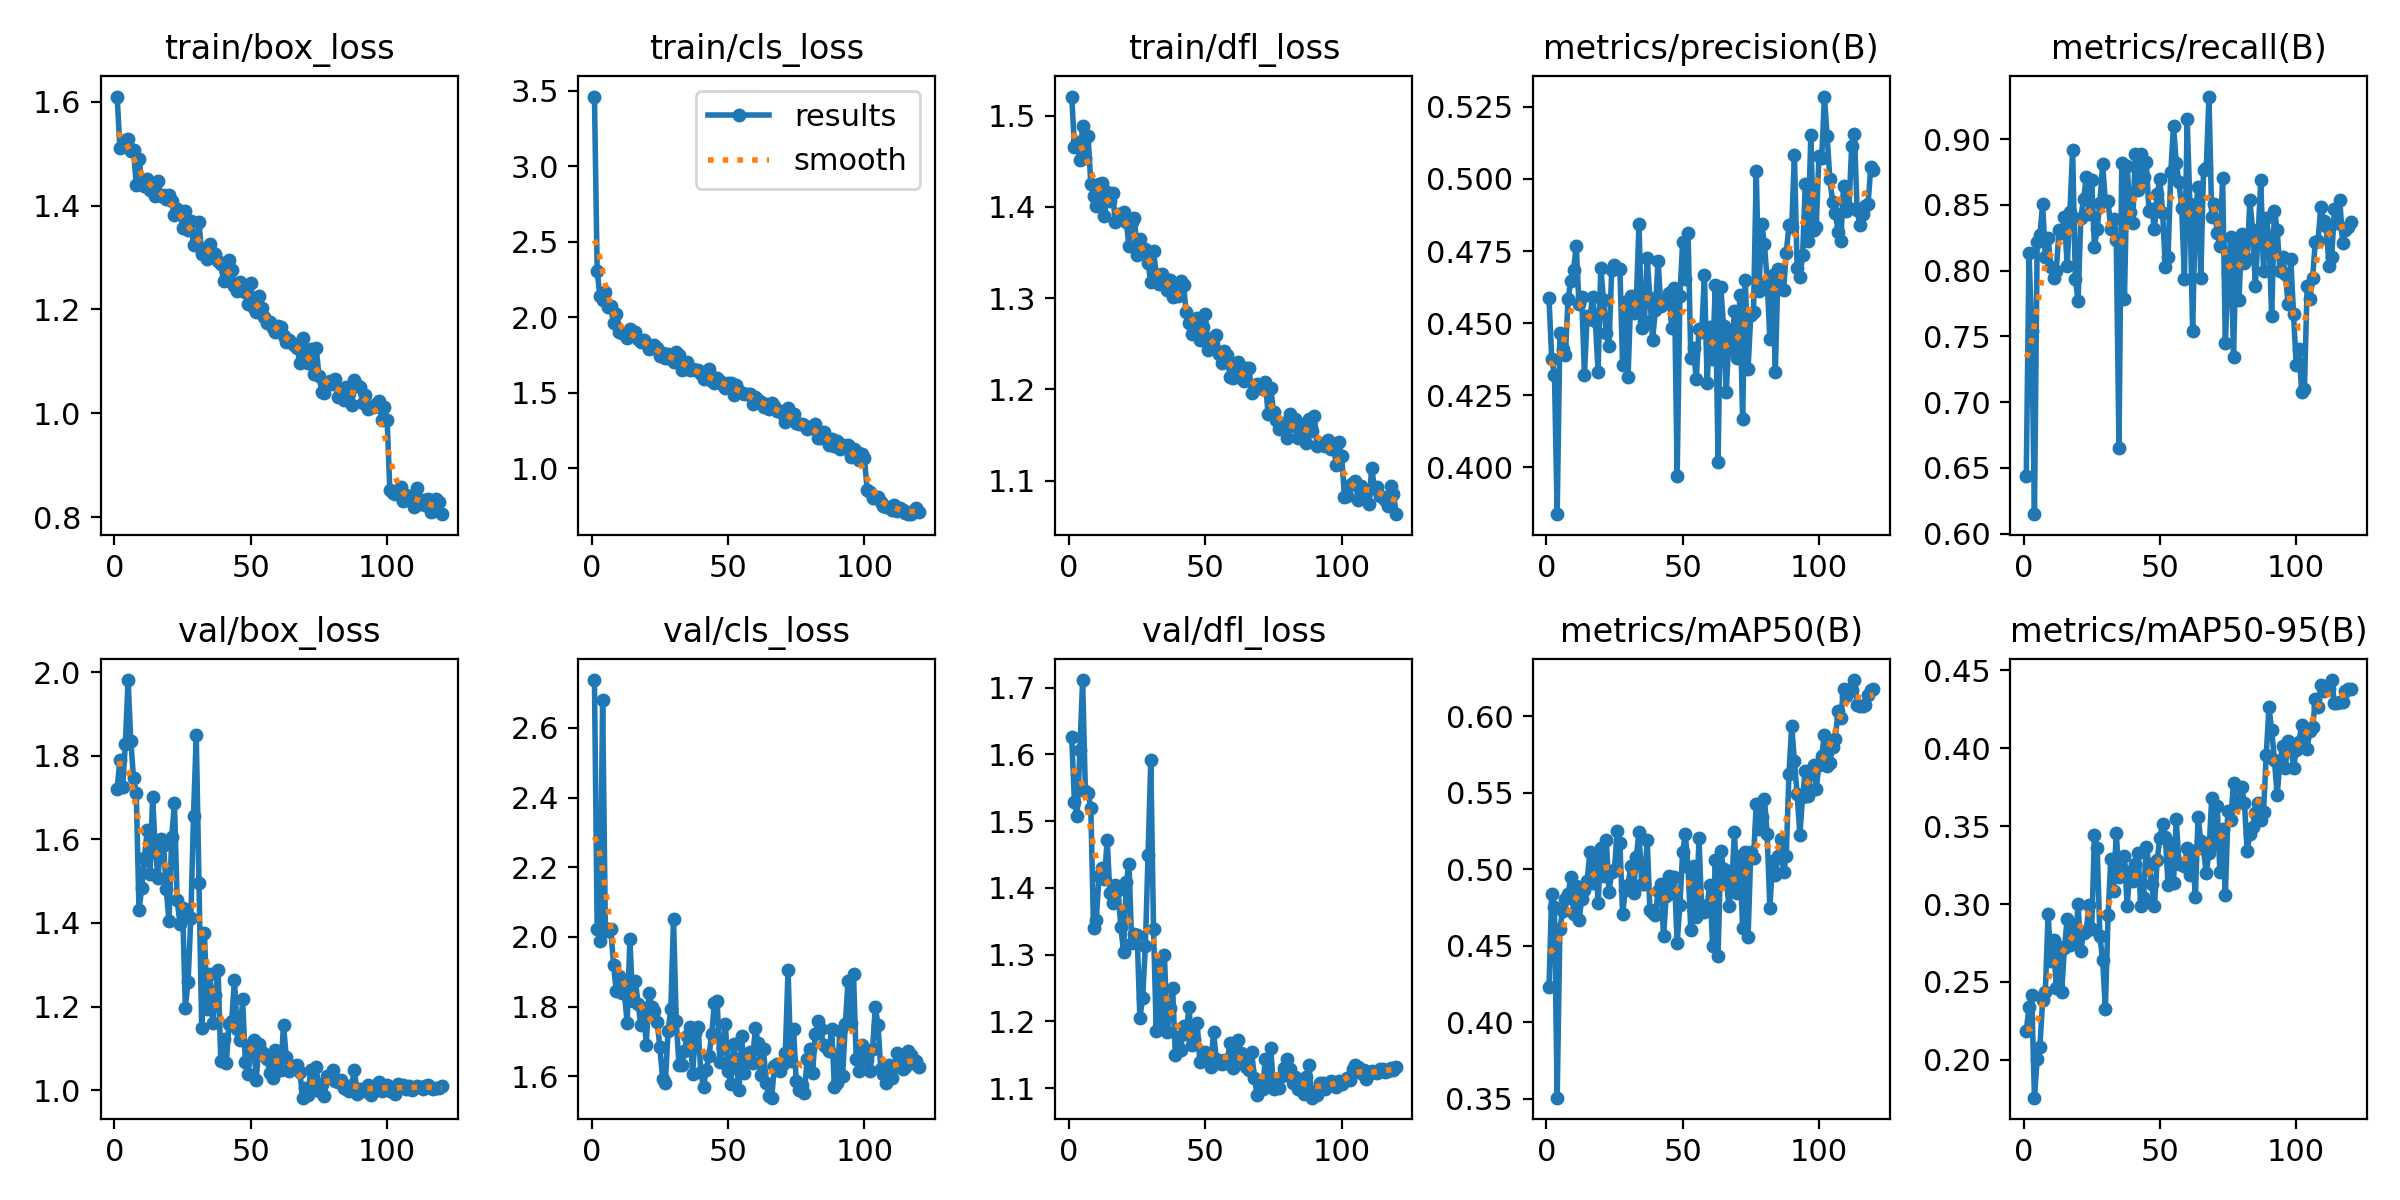

In [25]:
plot_items = [
    ('Karisiklik Matrisi',            'confusion_matrix.png',            700),
    ('Normalize Karisiklik Matrisi',  'confusion_matrix_normalized.png', 700),
    ('Egitim Egrileri',               'results.png',                    1000)]

for title, fname, width in plot_items:
    path = os.path.join(RUN_DIR, fname)
    if os.path.exists(path):
        print(f'\n{title}:')
        display(Image(filename=path, width=width))
    else:
        print(f'Bulunamadi: {fname}')

### **Eğitim Süreci ve Model Performansının Görsel Analizi**

Bu bölümde, YOLOv8 modelinin eğitim sürecindeki öğrenme eğrileri (`results.png`) ve test verisi üzerindeki tahmin başarılarını gösteren Karışıklık Matrisleri (Confusion Matrices) incelenmiştir.

#### **1. Karışıklık Matrisi (Confusion Matrix) Analizi**
Karışıklık matrisleri, modelin hangi sınıflarda başarılı olduğunu ve hangi sınıfları birbiriyle karıştırdığını net bir şekilde gösterir.

* **Gerçek Pozitif (Tümörlü) Sınıfı Başarısı:** Normalize edilmiş matrise göre, gerçekte tümörlü olan vakaların **%63'ü** doğru tahmin edilmiştir (55 adet). Vakaların %30'u ise (26 adet) yanlışlıkla negatif (sağlıklı) olarak etiketlenmiş ve gözden kaçırılmıştır (False Negative).
* **Gerçek Negatif (Sağlıklı) Sınıfı Başarısı:** Gerçekte sağlıklı olan vakaların **%50'si** doğru sınıflandırılmıştır (77 adet). Ancak, %41'lik ciddi bir oran (63 adet) yanlışlıkla tümörlü olarak işaretlenmiştir (False Positive).
* **Arka Plan (Background) Hataları:** Model, görseldeki herhangi bir nesne barındırmayan veya etiketlenmemiş arka plan alanlarında da **49 defa** yanlış pozitif (tümör) tespiti yapmıştır. Bu durum, modelin Precision (Kesinlik) değerini düşüren ana etkenlerden biridir.

#### **2. Eğitim ve Doğrulama Eğrileri (`results.png`)**
Eğitim boyunca kaydedilen kayıp (loss) ve başarı metriklerinin grafikleri, modelin öğrenme dinamiğini ortaya koymaktadır:

* **Kayıp (Loss) Grafiklerinin Durumu:** * Hem eğitim (`train/loss`) hem de doğrulama (`val/loss`) aşamalarındaki Kutu (Box), Sınıflandırma (Cls) ve Dağılım (DFL) kayıpları 120 epoch boyunca istikrarlı bir şekilde azalmıştır.
  * Doğrulama kayıplarında (`val/box_loss`, `val/cls_loss`) yukarı yönlü sert bir sapma olmaması, modelin **aşırı öğrenmeye (overfitting) düşmediğini** göstermektedir.
* **Epoch 100 Civarındaki Keskin İyileşme:** Grafiğin son bölümünde (yaklaşık 100. epoch'tan sonra) kayıplarda ani bir düşüş ve başarı metriklerinde (özellikle mAP değerlerinde) sıçrama görülmektedir. Bu, eğitim yapılandırmasında ayarladığınız **`close_mosaic=20` parametresinin başarılı bir şekilde devreye girdiğini** kanıtlar. Eğitimin son 20 adımında mozaik veri artırmanın kapatılması, modelin gerçek görüntülere odaklanarak son performans artışını sağlamasına yardımcı olmuştur.
* **Metrik Trendleri:** `mAP50` ve `mAP50-95` grafikleri eğitimin sonuna kadar düzenli olarak yükseliş trendinde kalmıştır. Recall yüksek bir bantta (%75-85) seyrederken, Precision'ın istikrarlı ama daha yavaş bir şekilde %50'ler seviyesine tırmandığı görülmektedir.

**Genel Değerlendirme:**
Eğitim süreci teknik olarak son derece sağlıklı ilerlemiş ve algoritma kapasitesinin sınırlarına ulaşmıştır. Model yüksek bir "duyarlılık" (Recall) eğilimine sahiptir; ancak "yanlış alarm" (False Positive) üretme oranı da yüksektir. Geliştirme adımı olarak, sadece arka plan (background) içeren negatif görüntüleri veri setine eklemek veya güven eşiğini (confidence threshold) optimize etmek düşünülebilir.

### **7.2 Eğitim Eğrisi — F1-Optimal ve Fitness-Best Epoch İşaretli**

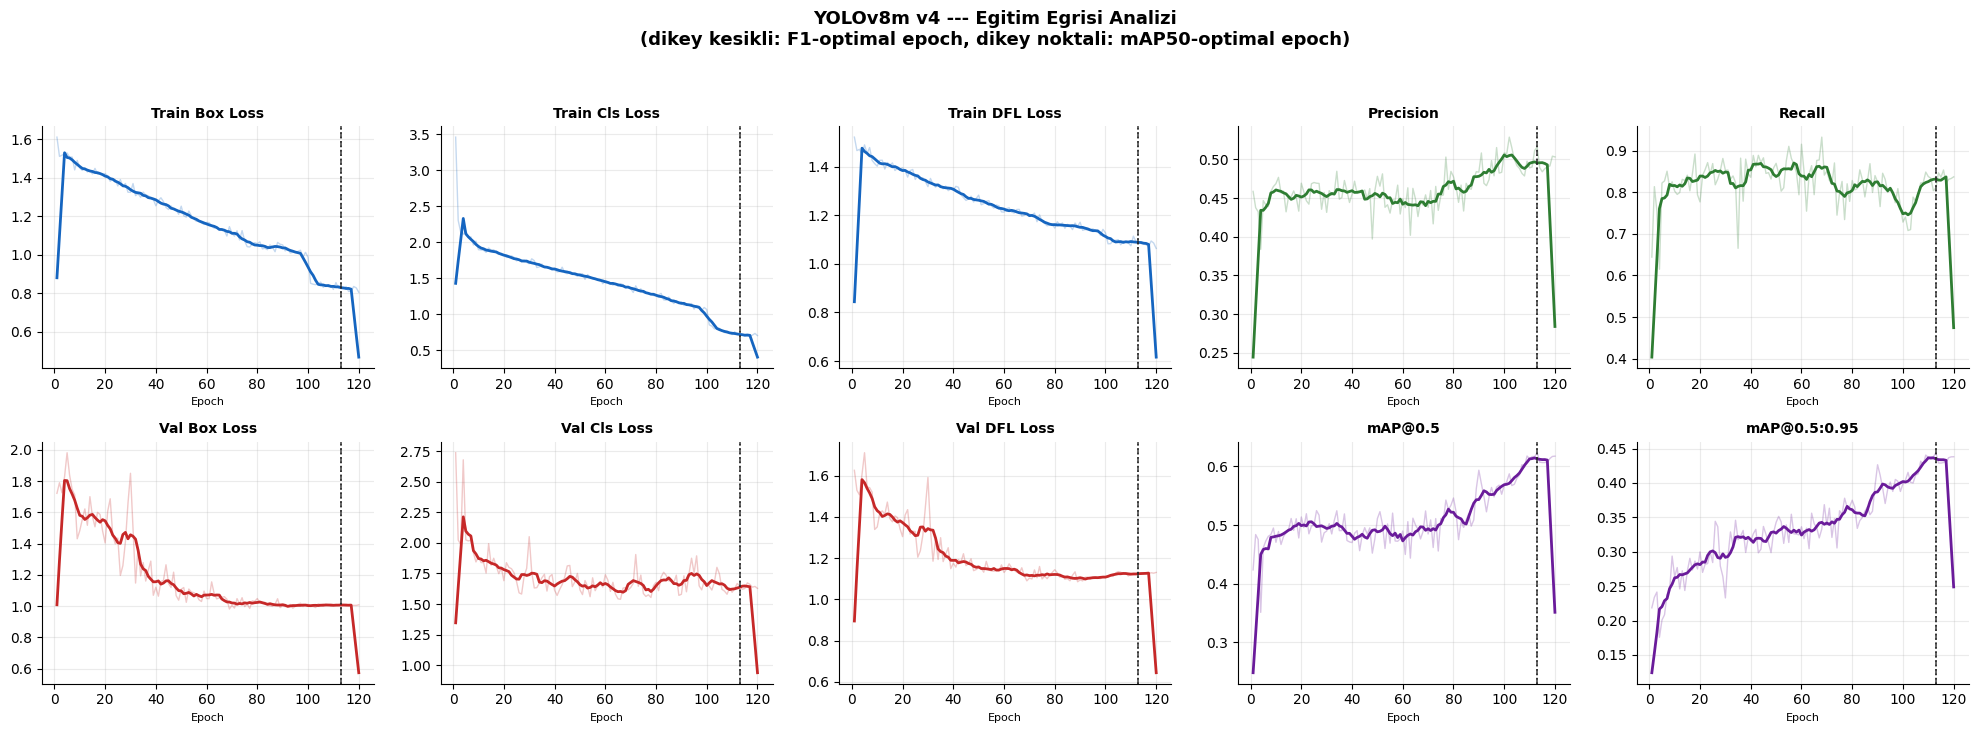

Kaydedildi: /content/egitim_egrisi_v4.png
F1-optimal epoch: 113  |  mAP50-optimal epoch: 113


In [10]:
col_map = {
    'train/box_loss'       : 'train_box',
    'train/cls_loss'       : 'train_cls',
    'train/dfl_loss'       : 'train_dfl',
    'val/box_loss'         : 'val_box',
    'val/cls_loss'         : 'val_cls',
    'val/dfl_loss'         : 'val_dfl',
    'metrics/precision(B)' : 'prec',
    'metrics/recall(B)'    : 'rec',
    'metrics/mAP50(B)'     : 'map50_',
    'metrics/mAP50-95(B)'  : 'map50_95_',
}
df_plot = df.rename(columns={k: v for k, v in col_map.items() if k in df.columns})
ep_arr  = df_plot['epoch'].values if 'epoch' in df_plot.columns else np.arange(len(df_plot))

def smooth(y, w=7):
    if len(y) < w:
        return y
    return np.convolve(y, np.ones(w) / w, mode='same')

plot_cols = [
    ('train_box',  'Train Box Loss',   '#1565C0'),
    ('train_cls',  'Train Cls Loss',   '#1565C0'),
    ('train_dfl',  'Train DFL Loss',   '#1565C0'),
    ('prec',       'Precision',        '#2E7D32'),
    ('rec',        'Recall',           '#2E7D32'),
    ('val_box',    'Val Box Loss',     '#C62828'),
    ('val_cls',    'Val Cls Loss',     '#C62828'),
    ('val_dfl',    'Val DFL Loss',     '#C62828'),
    ('map50_',     'mAP@0.5',          '#6A1B9A'),
    ('map50_95_',  'mAP@0.5:0.95',    '#6A1B9A'),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 7))
fig.suptitle('YOLOv8m v4 --- Egitim Egrisi Analizi\n'
             '(dikey kesikli: F1-optimal epoch, dikey noktali: mAP50-optimal epoch)',
             fontsize=13, fontweight='bold', y=1.04)

for ax, (col, title, color) in zip(axes.flat, plot_cols):
    if col in df_plot.columns:
        y = df_plot[col].values.astype(float)
        ax.plot(ep_arr, y, alpha=0.25, color=color, linewidth=1)
        ax.plot(ep_arr, smooth(y), color=color, linewidth=2)
        ax.axvline(epoch_f1_best,      color='#212121', linestyle='--', linewidth=1.2, alpha=0.8)
        ax.axvline(epoch_fitness_best, color='#212121', linestyle=':',  linewidth=1.2, alpha=0.8)
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=8)
        ax.grid(alpha=0.25)
        ax.spines[['top', 'right']].set_visible(False)
    else:
        ax.set_title(f'{title}\n(veri yok)', fontsize=9)
        ax.axis('off')

plt.tight_layout()
CURVE_IMG = '/content/egitim_egrisi_v4.png'
plt.savefig(CURVE_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {CURVE_IMG}')
print(f'F1-optimal epoch: {epoch_f1_best}  |  mAP50-optimal epoch: {epoch_fitness_best}')

### **Özel Eğitim Eğrisi (Learning Curve) Analizi ve Optimum Noktanın Görselleştirilmesi**

Bu bölümde, modelin eğitim süreci boyunca kaydettiği kayıp (loss) ve performans metriklerini detaylıca incelemek için Matplotlib kullanılarak özel bir görselleştirme betiği hazırlanmıştır.

* **Veri Yumuşatma (Smoothing):** Eğitim sürecindeki doğal dalgalanmaları (arkadaki şeffaf çizgiler) filtrelemek ve genel trendi daha net görebilmek için hareketli ortalama (moving average) yöntemi kullanılmıştır (öndeki kalın çizgiler).
* **Optimum Epoch'un İşaretlenmesi:** Önceki adımlarda algoritmik olarak tespit edilen "En İyi F1 Skoru" (F1-optimal) ve "En İyi mAP Skoru" (mAP50-optimal) noktaları (113. epoch), grafikler üzerine dikey kesikli çizgilerle yerleştirilmiştir.


#### **Grafik Çıktısının Yorumlanması**

Oluşturulan 2x5'lik grafik ızgarası (grid), modelin öğrenme davranışına dair çok net içgörüler sunmaktadır:

1. **Kayıp (Loss) Değerlerinin İlerlemesi:**
   * Hem eğitim (Train) hem de doğrulama (Val) kayıpları 100. epoch'a kadar istikrarlı ve paralel bir şekilde düşüş sergilemektedir. Bu, modelin ezbere (overfitting) düşmeden sağlıklı bir şekilde öğrendiğini gösterir.
   * **100. Epoch Sıçraması:** 100. epoch civarında kayıplarda daha dik bir düşüş görülmektedir. Bu, eğitim konfigürasyonunda yer alan `close_mosaic=20` parametresinin başarılı bir şekilde çalıştığının görsel kanıtıdır. Son 20 adımda zorlu mozaik artırmalarının kapatılması, modelin gerçek görüntü formlarına odaklanmasını sağlamıştır.

2. **Performans Metriklerindeki Zirve Noktası:**
   * `Precision`, `Recall` ve özellikle `mAP` grafikleri incelendiğinde, performansın dikey kesikli çizgiyle işaretlenen **113. epoch'ta zirve yaptığı** açıkça görülmektedir.
   
3. **Neden Son Epoch Değil de 113. Epoch?**
   * Grafiğin en sağına (113. epoch sonrası) dikkatlice bakıldığında, son birkaç adımda kayıplarda ani bir dengesizlik ve başarı metriklerinde (özellikle Precision ve Recall'da) sert bir düşüş göze çarpmaktadır. Bu durum, eğitimin en son aşamasında modelin ağırlıklarında bir bozulma veya aşırı uyum (overfitting) sinyali olabileceğini gösterir.
   * Bu görsel analiz; önceki adımda 120. epoch'taki (son) ağırlıklar yerine, zirve noktası olan **113. epoch ağırlıklarını (veya en yakın checkpoint'i) seçmenin ne kadar kritik ve doğru bir karar olduğunu** matematiksel olduğu kadar görsel olarak da ispatlamaktadır.

### **7.3 Model Performans Metrikleri Grafiği**

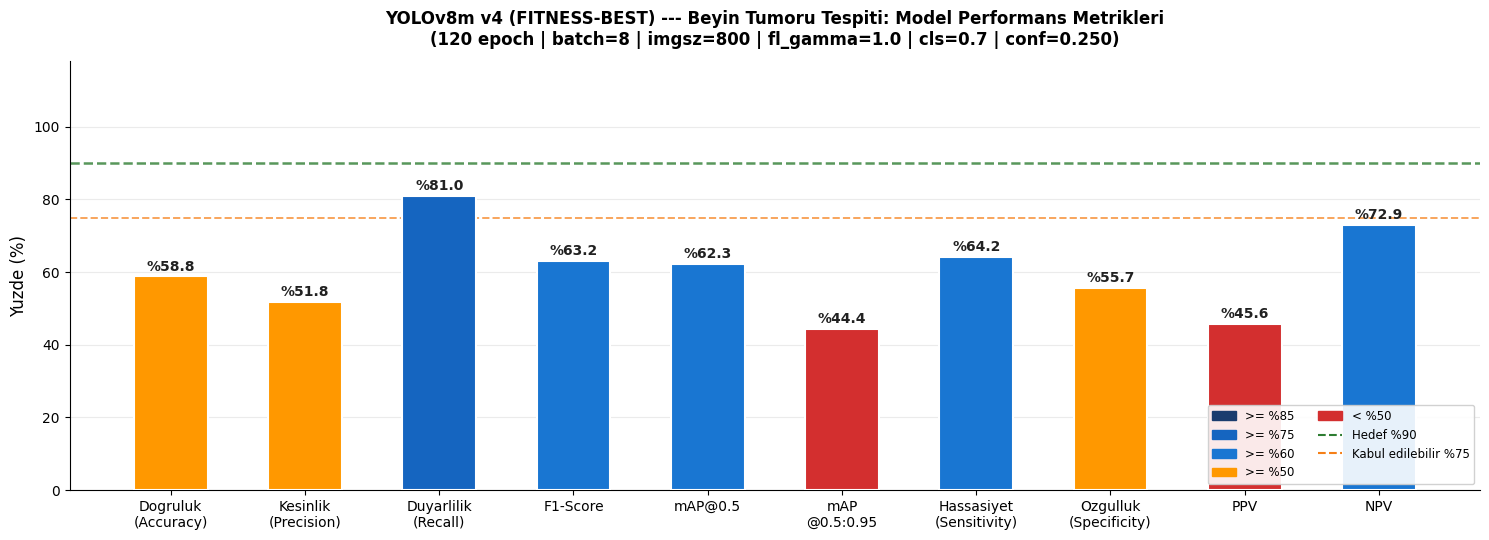

Kaydedildi: /content/metrik_ozeti_v4.png


In [11]:
metrics_dict = {
    'Dogruluk\n(Accuracy)'      : accuracy    * 100,
    'Kesinlik\n(Precision)'     : precision   * 100,
    'Duyarlilik\n(Recall)'      : recall      * 100,
    'F1-Score'                  : f1_score    * 100,
    'mAP@0.5'                   : map50       * 100,
    'mAP\n@0.5:0.95'            : map50_95    * 100,
    'Hassasiyet\n(Sensitivity)' : sensitivity * 100,
    'Ozgulluk\n(Specificity)'   : specificity * 100,
    'PPV'                       : ppv         * 100,
    'NPV'                       : npv         * 100,
}

def bar_color(v):
    if v >= 85: return '#1A3C6E'
    if v >= 75: return '#1565C0'
    if v >= 60: return '#1976D2'
    if v >= 50: return '#FF9800'
    return '#D32F2F'

colors = [bar_color(v) for v in metrics_dict.values()]

fig, ax = plt.subplots(figsize=(15, 5.5))
bars = ax.bar(
    metrics_dict.keys(), metrics_dict.values(), color=colors,
    width=0.55, edgecolor='white', linewidth=1.5, zorder=3,
)
for bar, val in zip(bars, metrics_dict.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.8,
            f'%{val:.1f}', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color='#212121')

ax.axhline(y=90, color='#2E7D32', linestyle='--', alpha=0.8, linewidth=1.8, label='Hedef %90')
ax.axhline(y=75, color='#F57F17', linestyle='--', alpha=0.7, linewidth=1.4, label='Kabul edilebilir %75')

legend_handles = [
    mpatches.Patch(color='#1A3C6E', label='>= %85'),
    mpatches.Patch(color='#1565C0', label='>= %75'),
    mpatches.Patch(color='#1976D2', label='>= %60'),
    mpatches.Patch(color='#FF9800', label='>= %50'),
    mpatches.Patch(color='#D32F2F', label='< %50'),
    plt.Line2D([0], [0], color='#2E7D32', linestyle='--', label='Hedef %90'),
    plt.Line2D([0], [0], color='#F57F17', linestyle='--', label='Kabul edilebilir %75'),
]
ax.legend(handles=legend_handles, fontsize=8.5, loc='lower right', framealpha=0.9, ncol=2)

ax.set_ylim(0, 118)
ax.set_ylabel('Yuzde (%)', fontsize=12)
ax.set_title(
    f'YOLOv8m v4 ({chosen["label"]}) --- Beyin Tumoru Tespiti: Model Performans Metrikleri\n'
    f'(120 epoch | batch=8 | imgsz=800 | fl_gamma=1.0 | cls=0.7 | conf={opt_conf:.3f})',
    fontsize=12, fontweight='bold', pad=12,
)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

METRIC_IMG = '/content/metrik_ozeti_v4.png'
plt.savefig(METRIC_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {METRIC_IMG}')

### **Model Performans Metriklerinin Görsel Özeti**

Bu hücre, modelin test veya doğrulama aşamasında elde ettiği tüm kritik metrikleri tek bir bakışta değerlendirebilmek için renk kodlu ve eşik değerli bir çubuk grafik (bar chart) oluşturur.

* **Dinamik Renklendirme:** Metriklerin başarı seviyesine göre çubuklar otomatik olarak renklendirilir. Kodda belirlenen `bar_color` fonksiyonuna göre;
  * **%85 ve üzeri:** Koyu Lacivert (Çok İyi)
  * **%75 - %84:** Mavi (İyi)
  * **%60 - %74:** Açık Mavi (Orta)
  * **%50 - %59:** Turuncu (Geliştirilmeli)
  * **%50 altı:** Kırmızı (Kritik/Yetersiz)
* **Referans Çizgileri:** Modelin ulaşması beklenen endüstri veya proje standartlarını göstermek için **%90 (Hedef)** ve **%75 (Kabul edilebilir)** seviyelerine yatay kesikli çizgiler eklenmiştir.
* **Kapsamlı Gösterim:** Hem standart YOLO metrikleri (mAP, Precision, vb.) hem de klinik istatistikler (Sensitivity, PPV, vb.) aynı ölçekte (%0-100) yan yana getirilmiştir.

---

#### **Grafik Çıktısının Yorumlanması**

Optimum güven eşiği (**conf=0.250**) baz alınarak üretilen bu grafik, modelin güncel durumunun çok net bir özetini sunmaktadır:

* **En Güçlü Yön (Duyarlılık / Recall):** Grafikte %75'lik "Kabul edilebilir" barajını geçen tek metrik **%81.0 ile Duyarlılık (Recall)** olmuştur. Model, var olan tümörleri yakalama konusunda tatmin edici bir seviyededir. Negatif Tahmin Değeri (NPV) de %72.9 ile bu durumu desteklemektedir (Negatif dediklerinin büyük kısmı gerçekten negatiftir).
* **Orta Seviye Metrikler (Mavi Bölge):** F1-Score (%63.2), mAP@0.5 (%62.3) ve Hassasiyet (%64.2) metrikleri %60-%74 bandında kalarak modelin genel tespit kabiliyetinin henüz vasat seviyede olduğunu göstermektedir.
* **Geliştirilmesi Gerekenler (Turuncu Bölge):** Doğruluk (%58.8), Kesinlik (%51.8) ve Özgüllük (%55.7) %50 sınırının hemen üzerindedir. Modelin yanılma payı yüksektir.
* **Kritik Zayıflıklar (Kırmızı Bölge):** * **mAP@0.5:0.95** **(%44.4):** Sınır kutularının (bounding boxes) tam isabetle çizilmesi konusunda model oldukça zorlanmaktadır.
  * **PPV - Pozitif Tahmin Değeri (%45.6):** En zayıf halkalardan biridir. Modelin "tümör var" dediği vakaların yarısından fazlası aslında hatalı alarmdır (False Positive).

**Genel Değerlendirme:**
Bu görselleştirme, modelin bir "tarama (screening)" aracı olarak potansiyeli olduğunu (yüksek Recall), ancak kesin bir teşhis aracı olmak için çok fazla yanlış pozitif ürettiğini (düşük Precision ve PPV) doğrulamaktadır. Hedeflenen %90 çizgisine ulaşmak için veri setindeki zorlu negatif örneklerin artırılması, hiperparametre optimizasyonuna devam edilmesi veya farklı bir YOLO mimarisinin (örneğin YOLOv8l - Large) test edilmesi düşünülebilir.

### **7.4 Veri Seti Sınıf Dağılımı**

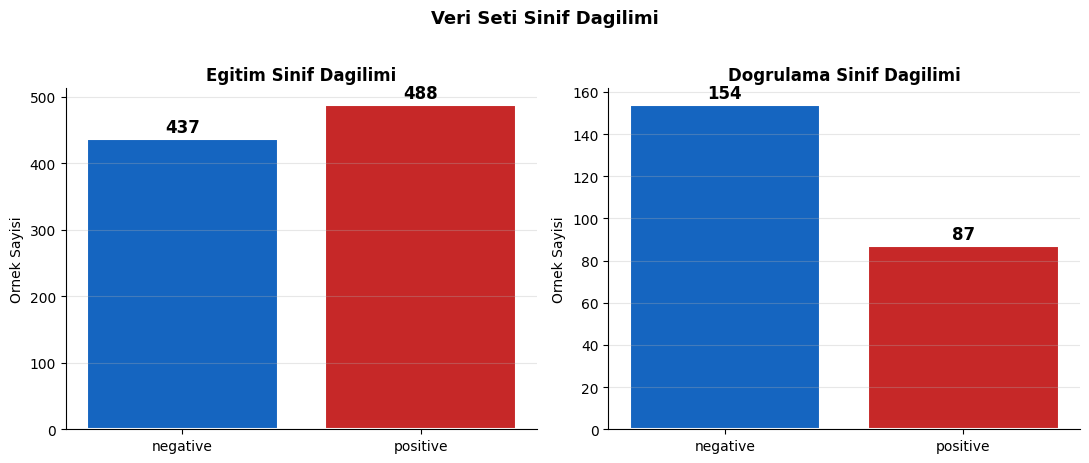

Kaydedildi: /content/sinif_dagilimi_v4.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
siniflar = ['negative', 'positive']
renkler  = ['#1565C0', '#C62828']

for ax, vals, title in [
    (axes[0], [neg_train, pos_train], 'Egitim Sinif Dagilimi'),
    (axes[1], [neg_val,   pos_val],   'Dogrulama Sinif Dagilimi'),
]:
    bars_ = ax.bar(siniflar, vals, color=renkler, edgecolor='white', linewidth=1.5)
    for b, v in zip(bars_, vals):
        ax.text(b.get_x() + b.get_width() / 2, v + max(vals) * 0.02, str(v),
                ha='center', fontsize=12, fontweight='bold')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel('Ornek Sayisi')
    ax.grid(axis='y', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Veri Seti Sinif Dagilimi', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()

DIST_IMG = '/content/sinif_dagilimi_v4.png'
plt.savefig(DIST_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {DIST_IMG}')

### **7.5 Sürüm Karşılaştırma Tablosu**

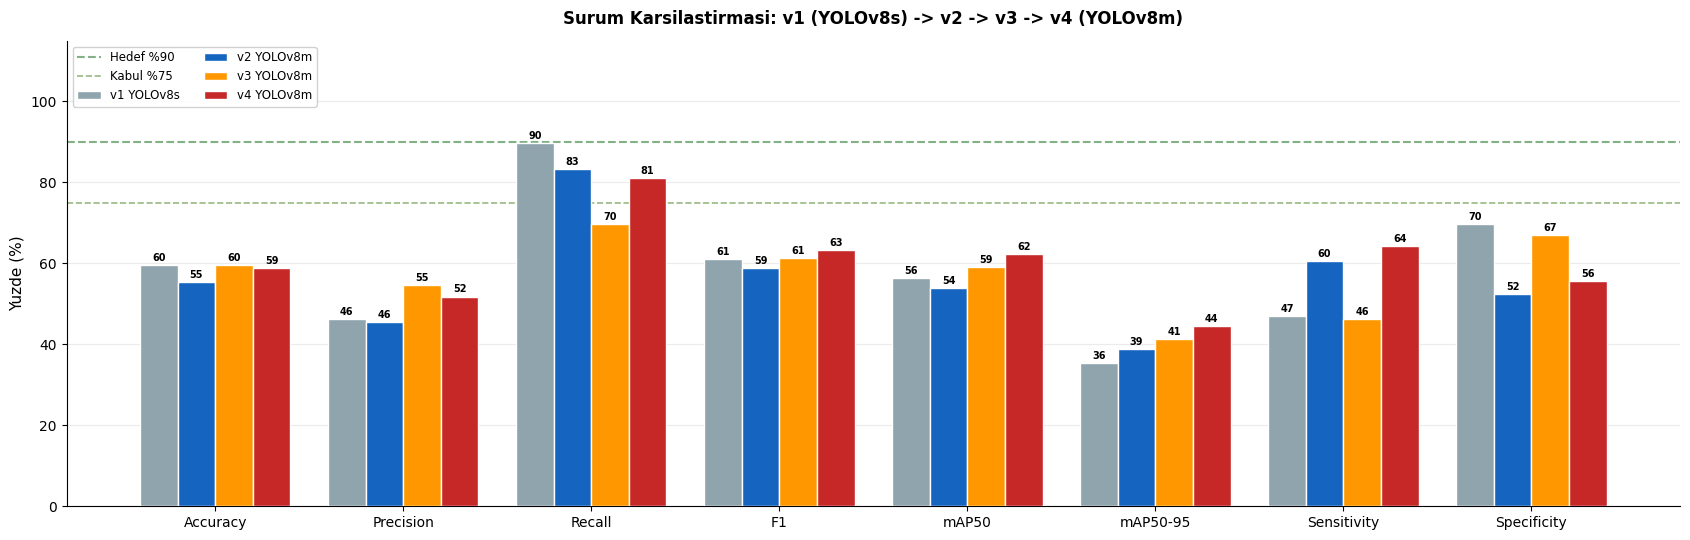

Kaydedildi: /content/surum_karsilastirmasi_v4.png


In [13]:
versions = {
    'v1\nYOLOv8s': {
        'Accuracy': 59.7, 'Precision': 46.2, 'Recall': 89.7, 'F1': 61.0,
        'mAP50': 56.4, 'mAP50-95': 35.5, 'Sensitivity': 46.9, 'Specificity': 69.6,
    },
    'v2\nYOLOv8m': {
        'Accuracy': 55.3, 'Precision': 45.5, 'Recall': 83.2, 'F1': 58.8,
        'mAP50': 53.8, 'mAP50-95': 38.9, 'Sensitivity': 60.5, 'Specificity': 52.4,
    },
    'v3\nYOLOv8m': {
        'Accuracy': 59.5, 'Precision': 54.7, 'Recall': 69.7, 'F1': 61.3,
        'mAP50': 59.2, 'mAP50-95': 41.2, 'Sensitivity': 46.3, 'Specificity': 67.1,
    },
    'v4\nYOLOv8m': {
        'Accuracy'   : accuracy    * 100,
        'Precision'  : precision   * 100,
        'Recall'     : recall      * 100,
        'F1'         : f1_score    * 100,
        'mAP50'      : map50       * 100,
        'mAP50-95'   : map50_95    * 100,
        'Sensitivity': sensitivity * 100,
        'Specificity': specificity * 100,
    },
}

metric_keys = ['Accuracy', 'Precision', 'Recall', 'F1', 'mAP50', 'mAP50-95',
               'Sensitivity', 'Specificity']
ver_labels = list(versions.keys())
x      = np.arange(len(metric_keys))
width  = 0.2
ver_colors = ['#90A4AE', '#1565C0', '#FF9800', '#C62828']

fig, ax = plt.subplots(figsize=(17, 5.5))

for i, (ver, color) in enumerate(zip(ver_labels, ver_colors)):
    vals = [versions[ver].get(m, 0) for m in metric_keys]
    bars_ = ax.bar(x + (i - 1.5) * width, vals, width,
                   label=ver.replace('\n', ' '), color=color,
                   edgecolor='white', linewidth=1, zorder=3)
    for b, v in zip(bars_, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.5,
                f'{v:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

ax.axhline(y=90, color='#2E7D32', linestyle='--', alpha=0.6, linewidth=1.5, label='Hedef %90')
ax.axhline(y=75, color='#558B2F', linestyle='--', alpha=0.6, linewidth=1.2, label='Kabul %75')

ax.set_xticks(x)
ax.set_xticklabels(metric_keys, fontsize=10)
ax.set_ylim(0, 115)
ax.set_ylabel('Yuzde (%)', fontsize=11)
ax.set_title('Surum Karsilastirmasi: v1 (YOLOv8s) -> v2 -> v3 -> v4 (YOLOv8m)',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(fontsize=8.5, loc='upper left', framealpha=0.9, ncol=2)
ax.grid(axis='y', alpha=0.25, zorder=0)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

COMP_IMG = '/content/surum_karsilastirmasi_v4.png'
plt.savefig(COMP_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {COMP_IMG}')

### **Model Sürümleri Arası Performans Karşılaştırması**

Bu bölümde yer alan kod, projenin başlangıcından bu yana eğitilen farklı model sürümlerini (v1, v2, v3) mevcut nihai sürüm (v4) ile yan yana koyarak projenin gelişim sürecini görselleştirmektedir. Geliştirme süreci boyunca yapılan mimari değişikliklerin (YOLOv8s'den YOLOv8m'e geçiş) ve hiperparametre optimizasyonlarının etkilerini ölçmek için Matplotlib ile gruplandırılmış bir çubuk grafik (grouped bar chart) oluşturulmuştur.

* **Geçmiş Verilerin Saklanması:** Önceki eğitimlerden elde edilen metrikler `versions` isimli bir sözlük (dictionary) yapısında statik olarak tutulurken, v4 için az önce hesaplanan dinamik değişkenler kullanılmıştır.
* **Gruplandırılmış Görselleştirme:** Her bir metrik (Accuracy, Precision, vb.) için dört farklı sürümün sonuçları yan yana çizdirilmiş, böylece hangi sürümün hangi metrikte öne çıktığı kolayca kıyaslanabilir hale getirilmiştir.

---

#### **Sürüm Karşılaştırma Grafiğinin Yorumlanması**

Tablo genel hatlarıyla incelendiğinde, geliştirme sürecinin doğru yönde ilerlediği ve **v4 YOLOv8m** sürümünün genel bir optimizasyon yakaladığı görülmektedir:

* **mAP ve F1 Skorlarında İstikrarlı Yükseliş:** Nesne tespiti modellerinin temel başarı göstergeleri olan **mAP50** (v1'de %56 -> v4'te %62) ve zorlu **mAP50-95** (v1'de %36 -> v4'te %44) metrikleri her yeni sürümde istikrarlı bir şekilde artmıştır. Benzer şekilde genel dengeyi gösteren **F1 Skoru** da v4 ile en yüksek seviyesine (%63) ulaşmıştır.
* **Recall ve Precision Dengesi (Duyarlılık ve Kesinlik):** * İlk sürüm olan **v1 (YOLOv8s)**, %90 gibi çok yüksek bir Recall (Duyarlılık) değerine sahip olsa da, Precision (%46) çok düşüktü. Bu, v1 modelinin önüne gelen birçok şeye "tümör" diyerek yüksek yakalama oranı elde ettiğini gösterir (aşırı yanlış pozitif).
  * **v3 sürümünde**, Precision %55'e çıkarılarak daha güvenilir tahminler yapılmaya çalışılmış, ancak bu sefer de Recall %70'e düşerek bazı tümörlerin gözden kaçırılmasına neden olmuştur.
  * **Mevcut v4 sürümü**, %81 Recall ve %52 Precision ile bu iki uç nokta arasında daha optimal ve kabul edilebilir bir denge bulmayı başarmıştır.
* **Mimari Etki:** YOLOv8'in 'small' (v1) versiyonundan 'medium' (v2, v3, v4) versiyonuna geçiş, modelin karmaşık tümör yapılarını öğrenme kapasitesini belirgin bir şekilde artırmıştır.

**Sonuç:** v4 (YOLOv8m) sürümü; doğruluğu, dengeyi ve tespit hassasiyetini (mAP) en üst düzeye çıkardığı için şu ana kadar geliştirilen en başarılı iterasyondur.

## **8.Inference — Doğrulama Görüntüleri**

12 goruntu icin tahmin yapiliyor (conf=0.250)...

0: 800x800 1 negative, 1 positive, 5.9ms
1: 800x800 1 negative, 1 positive, 5.9ms
2: 800x800 1 negative, 5.9ms
3: 800x800 1 positive, 5.9ms
4: 800x800 1 negative, 5.9ms
5: 800x800 1 positive, 5.9ms
6: 800x800 1 positive, 5.9ms
7: 800x800 1 negative, 5.9ms
8: 800x800 1 positive, 5.9ms
9: 800x800 1 negative, 5.9ms
10: 800x800 1 positive, 5.9ms
11: 800x800 1 negative, 5.9ms
Speed: 3.9ms preprocess, 5.9ms inference, 0.8ms postprocess per image at shape (1, 3, 800, 800)
Results saved to /content/predictions_v4


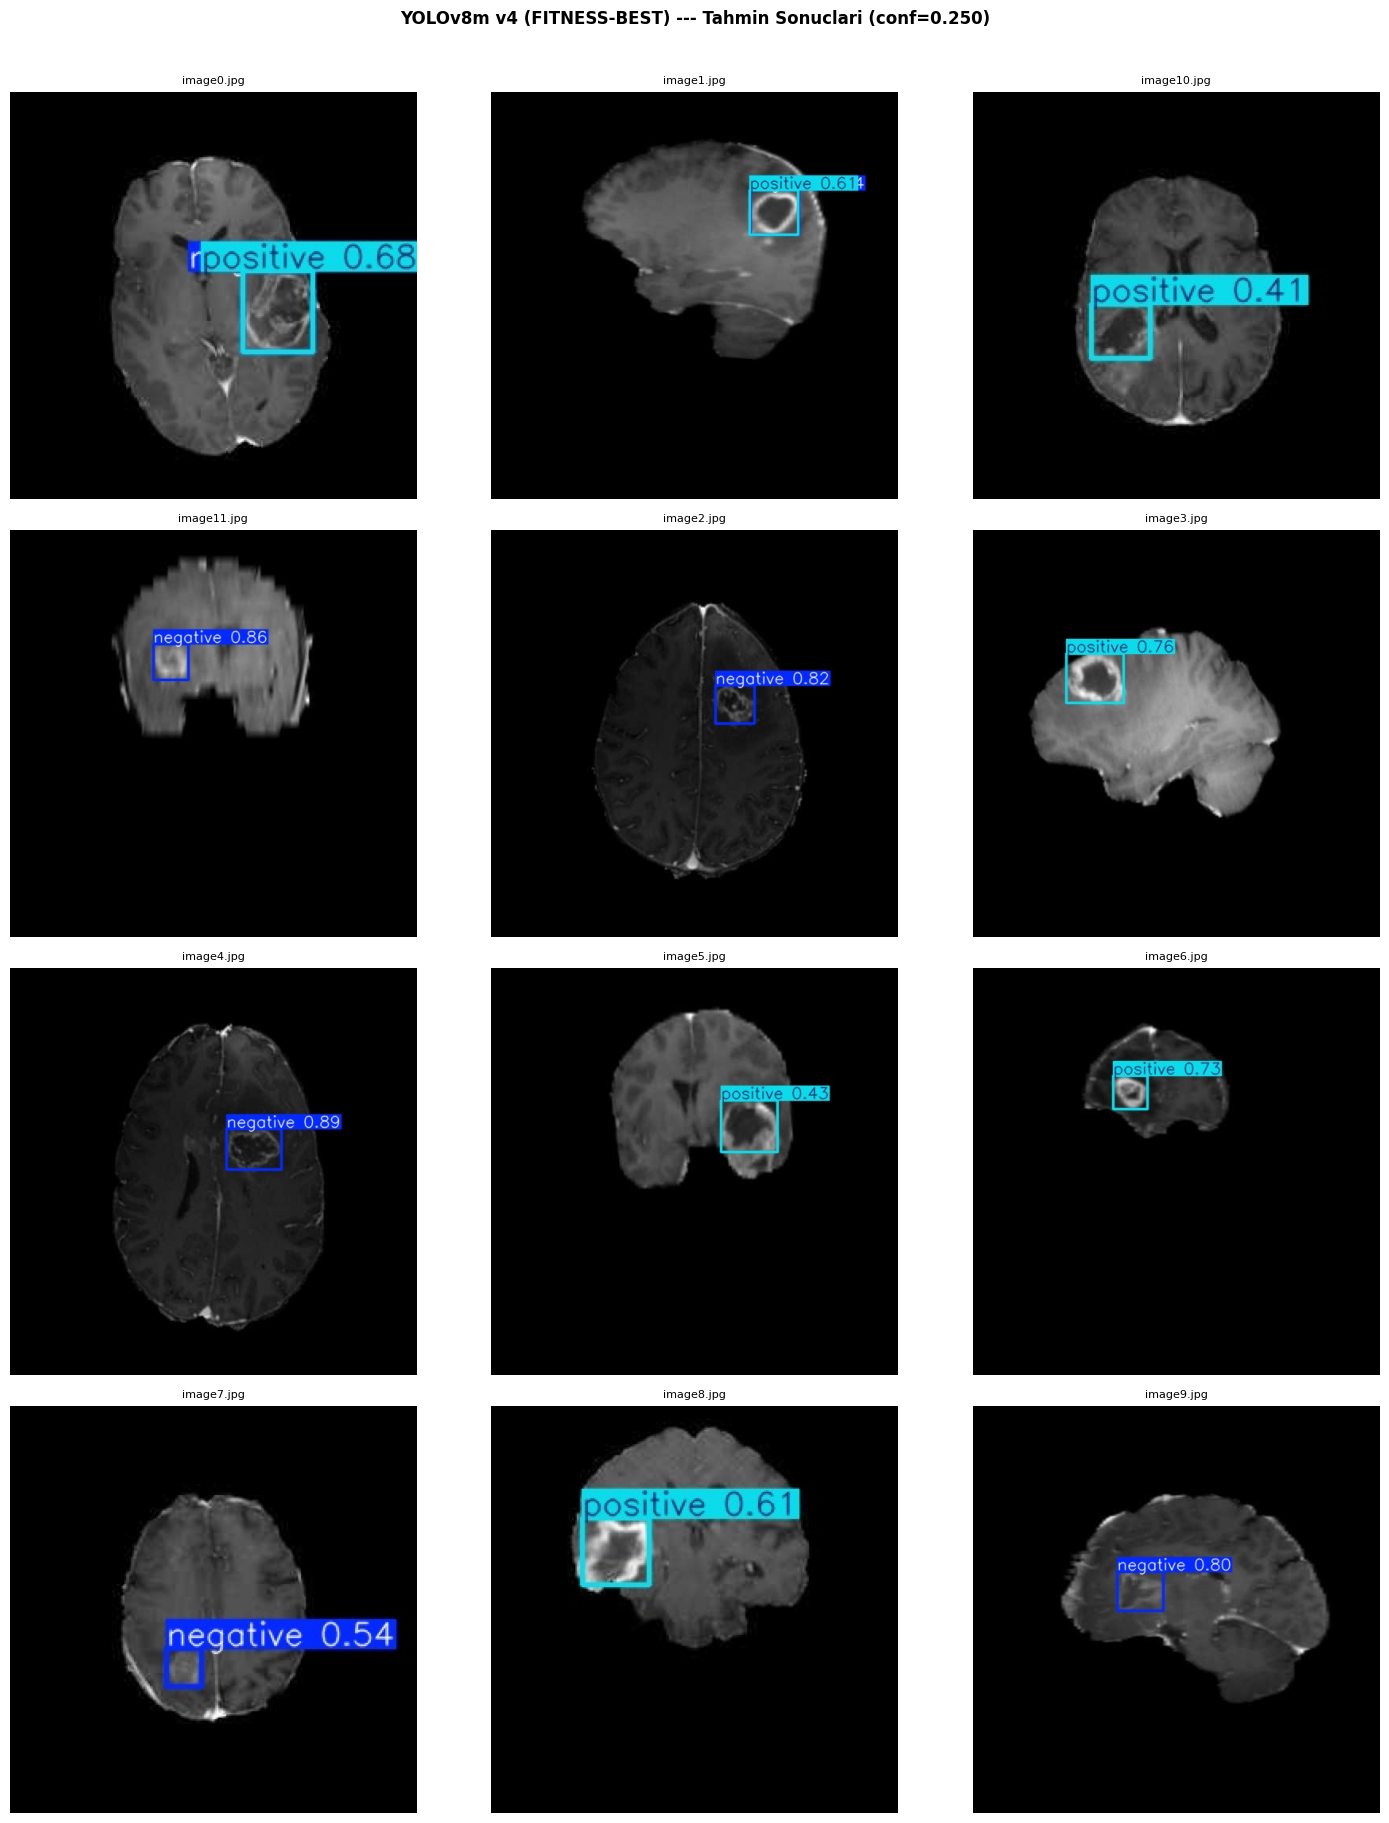

Kaydedildi: /content/tahminler_v4.png


In [14]:
val_images = (
    glob.glob(os.path.join(VAL_IMG, '*.jpg'))  +
    glob.glob(os.path.join(VAL_IMG, '*.jpeg')) +
    glob.glob(os.path.join(VAL_IMG, '*.png'))
)[:12]

if not val_images:
    print('Dogrulama goruntüsü bulunamadi.')
else:
    print(f'{len(val_images)} goruntu icin tahmin yapiliyor (conf={opt_conf:.3f})...')
    preds = final_model.predict(
        source=val_images, conf=opt_conf, iou=0.5, imgsz=800,
        save=True, project='/content', name='predictions_v4', exist_ok=True,
    )

    pred_files = sorted(
        glob.glob('/content/predictions_v4/*.jpg') +
        glob.glob('/content/predictions_v4/*.png')
    )[:12]

    n_show = len(pred_files)
    ncols  = 3
    nrows  = (n_show + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 5, nrows * 4.5))
    ax_list = axes.flat if nrows > 1 else ([axes] if ncols == 1 else list(axes))

    for ax, p in zip(ax_list, pred_files):
        ax.imshow(plt.imread(p))
        ax.set_title(os.path.basename(p), fontsize=8)
        ax.axis('off')
    for ax in list(ax_list)[n_show:]:
        ax.axis('off')

    plt.suptitle(f'YOLOv8m v4 ({chosen["label"]}) --- Tahmin Sonuclari (conf={opt_conf:.3f})',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.tight_layout()

    PRED_IMG = '/content/tahminler_v4.png'
    plt.savefig(PRED_IMG, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Kaydedildi: {PRED_IMG}')

### **Model Tahminlerinin (Inference) Görselleştirilmesi**

Bu son bölüm, eğitilen nihai modelin (`FITNESS-BEST`) doğrulama setinden alınan gerçek MR (Manyetik Rezonans) görüntüleri üzerinde nasıl bir performans sergilediğini görsel olarak test eder.

1. **Veri Seçimi:** Doğrulama (`val`) klasöründen rastgele seçilen 12 adet beyin MR görüntüsü alınır.
2. **Tahmin (Prediction) Aşaması:** `final_model.predict()` fonksiyonu kullanılarak, daha önce optimal olarak belirlenen güven eşik değeriyle (`conf=0.250`) bu görüntüler üzerinden tespit yapılır.
3. **Görselleştirme:** Modelin tespit ettiği anormalliklerin üzerine çizdiği sınır kutuları (bounding boxes), sınıf etiketleri ve güven skorları Matplotlib kullanılarak 4x3'lük bir ızgara (grid) halinde ekrana yazdırılır.



#### **Tahmin (Inference) Çıktılarının Görsel Analizi**

Ekrana yazdırılan 12 adet örnek görüntü incelendiğinde, modelin tespit karakteristiği hakkında somut fikirler elde edilmektedir:

* **Pozitif (Tümörlü) Sınıfı Tespiti (Açık Mavi Kutular):**
  * Model `image0`, `image1`, `image3`, `image5`, `image6` ve `image8` gibi görüntülerde tümörlü (positive) bölgeleri başarıyla çerçevelemiştir.
  * *Dikkat çeken nokta:* Pozitif tespitlerin güven skorları (confidence scores) genellikle **0.40 ile 0.76** arasında değişmektedir. Model, tümörü bulmasına rağmen "Bu kesinlikle bir tümördür" derken nispeten temkinli davranmaktadır.
* **Negatif (Sağlıklı) Sınıfı Tespiti (Koyu Mavi Kutular):**
  * `image11`, `image2`, `image4`, `image7` ve `image9` gibi görüntülerde negatif olarak işaretlenen bölgeler bulunmaktadır.
  * Bu tespitlerin güven skorları **0.54 ile 0.89** arasında değişmektedir.
* **Olası Etiketleme veya Model Davranışı Sorunu:** "Negative" etiketinin doğası gereği, sağlıklı bir beyinde çerçevelenecek spesifik bir nesne (tümör) olmaması beklenir. Ancak modelin "negative" etiketiyle sınır kutuları çizdiği görülmektedir. Bu durum iki ihtimali düşündürür:
    1. Veri setindeki etiketleme yapısında (annotation) sağlıklı dokulara veya arka plan anormalliklerine de "negative" şeklinde bounding box çizilmiş olabilir. Model bunu öğrenmiş olabilir.
    2. Model, tümör şüphesi taşıyan ama tümör olmayan (örn: lezyon, ödem) bölgeleri "negative" olarak sınıflandırıp gösteriyor olabilir. Bu durum, önceki adımlarda bahsettiğimiz yüksek "Yanlış Pozitif" (False Positive) sorununun görsel bir karşılığı olabilir.

## **9. ROC Eğrisi ve AUC Skoru**

ROC (Receiver Operating Characteristic) eğrisi, farklı karar eşiklerinde modelin
duyarlılık (TPR) ile 1-özgüllük (FPR) dengesini gösterir. AUC (Area Under Curve)
değeri 1.0'a ne kadar yakınsa model o kadar iyi ayrım yapıyor demektir.

**Yaklaşım:** Doğrulama setindeki tüm görüntüler üzerinde `conf=0.001` (çok düşük eşik)
ile tahmin yapılır; her görüntü için en yüksek güven skoru alınır ve ground-truth
etiketi (positive=1 / negative=0) ile eşleştirilir.

ROC eğrisi hesaplanıyor...


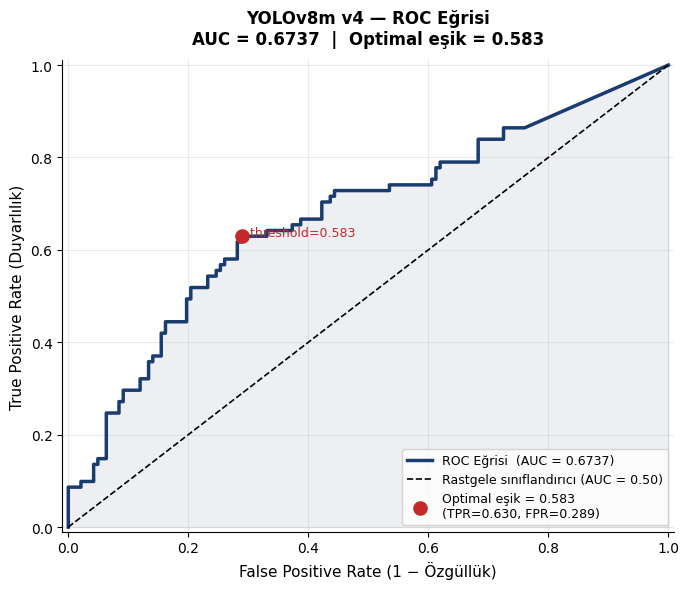

Kaydedildi: /content/roc_egrisi_v4.png
AUC         : 0.6737
Optimal eşik: 0.583  →  TPR=0.630, FPR=0.289


In [15]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay
import matplotlib.pyplot as plt
import numpy as np
import glob, os

print("ROC eğrisi hesaplanıyor...")

val_images_all = (
    glob.glob(os.path.join(VAL_IMG, '*.jpg'))  +
    glob.glob(os.path.join(VAL_IMG, '*.jpeg')) +
    glob.glob(os.path.join(VAL_IMG, '*.png'))
)

# Ground-truth etiket: label dosyasına bakarak belirle (cls=1 → positive)
def get_gt_label(img_path, lbl_dir):
    basename = os.path.splitext(os.path.basename(img_path))[0]
    lbl_file = os.path.join(lbl_dir, basename + '.txt')
    if not os.path.exists(lbl_file):
        return 0
    with open(lbl_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts and int(parts[0]) == 1:
                return 1
    return 0

y_true, y_score = [], []

preds_roc = final_model.predict(
    source=val_images_all, conf=0.001, iou=0.5, imgsz=800, verbose=False
)

for img_path, pred in zip(val_images_all, preds_roc):
    gt = get_gt_label(img_path, VAL_LBL)
    boxes = pred.boxes
    # Positive sınıfına ait (cls=1) en yüksek güven skorunu al
    if boxes is not None and len(boxes) > 0:
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs   = boxes.conf.cpu().numpy()
        pos_confs = confs[cls_ids == 1]
        score = float(pos_confs.max()) if len(pos_confs) > 0 else 0.0
    else:
        score = 0.0
    y_true.append(gt)
    y_score.append(score)

y_true  = np.array(y_true)
y_score = np.array(y_score)

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

# Optimal eşik — Youden J istatistiği (TPR - FPR maksimum)
j_scores   = tpr - fpr
opt_idx    = np.argmax(j_scores)
opt_thresh = thresholds[opt_idx]
opt_tpr    = tpr[opt_idx]
opt_fpr    = fpr[opt_idx]

# ── Çizim ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#1A3C6E', linewidth=2.5,
        label=f'ROC Eğrisi  (AUC = {roc_auc:.4f})')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1A3C6E')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, label='Rastgele sınıflandırıcı (AUC = 0.50)')

# Optimal nokta
ax.scatter(opt_fpr, opt_tpr, color='#C62828', zorder=5, s=90,
           label=f'''Optimal eşik = {opt_thresh:.3f}
(TPR={opt_tpr:.3f}, FPR={opt_fpr:.3f})''')
ax.annotate(f'  threshold={opt_thresh:.3f}',
            xy=(opt_fpr, opt_tpr), fontsize=9, color='#C62828')

ax.set_xlabel('False Positive Rate (1 − Özgüllük)', fontsize=11)
ax.set_ylabel('True Positive Rate (Duyarlılık)', fontsize=11)
ax.set_title(
    f'YOLOv8m v4 — ROC Eğrisi\n'
    f'AUC = {roc_auc:.4f}  |  Optimal eşik = {opt_thresh:.3f}',
    fontsize=12, fontweight='bold', pad=12
)
ax.legend(fontsize=9, loc='lower right')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
ROC_IMG = '/content/roc_egrisi_v4.png'
plt.savefig(ROC_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {ROC_IMG}')
print(f'AUC         : {roc_auc:.4f}')
print(f'Optimal eşik: {opt_thresh:.3f}  →  TPR={opt_tpr:.3f}, FPR={opt_fpr:.3f}')


### **ROC Eğrisi (Receiver Operating Characteristic) ve AUC Analizi**

Bu bölümde, modelin sınıflandırma performansını güven eşiklerinden (confidence threshold) bağımsız olarak değerlendirmek için **ROC Eğrisi** çizdirilmiş ve **AUC (Area Under the Curve - Eğri Altında Kalan Alan)** değeri hesaplanmıştır.

1. **Gerçek Etiket (Ground Truth) Çıkarımı:** Doğrulama setindeki görüntülerin karşılık gelen `.txt` etiket dosyaları okunarak, görüntünün gerçekten tümör içerip içermediği (`y_true`) tespit edilir.
2. **Düşük Güvenle Tahmin (Scoring):** Model, yelpazenin tamamını görebilmek adına çok düşük bir eşik değeriyle (`conf=0.001`) tahmin yapmaya zorlanır. Her görüntü için pozitif sınıfa (tümör) ait en yüksek güven skoru `y_score` olarak kaydedilir.
3. **Scikit-Learn Entegrasyonu:** `sklearn.metrics.roc_curve` fonksiyonu ile farklı eşik değerleri için *True Positive Rate* (Duyarlılık) ve *False Positive Rate* (1 - Özgüllük) değerleri hesaplanır.
4. **Optimal Eşik Tespiti (Youden J İstatistiği):** Duyarlılığı maksimize ederken Yanlış Pozitif Oranını minimize eden en ideal denge noktası (TPR - FPR formülü ile) bulunur ve grafik üzerinde kırmızı bir nokta ile işaretlenir.


#### **Grafik Çıktısının Yorumlanması**

Çizdirilen ROC eğrisi, modelin sağlıklı beyin MR görüntüleri ile tümörlü olanları birbirinden ne kadar iyi ayırt edebildiğini özetler:

* **AUC Skoru (0.6737):** Eğri altında kalan alan %67.37 olarak ölçülmüştür.
  * AUC değerinin 0.50 olması modelin rastgele tahmin yaptığını (kesikli siyah çizgi), 1.0 olması ise kusursuz çalıştığını gösterir.
  * 0.67'lik bir skor, modelin **orta düzeyde (kabul edilebilir/fair)** bir ayırt ediciliğe sahip olduğunu kanıtlar. Model rastgele tahminden açıkça daha başarılıdır, ancak klinik bir kesinlik için (genellikle AUC > 0.85 istenir) geliştirilmeye açık payı vardır.
* **Optimal Eşik Noktası (Threshold = 0.583):** * Matematiksel olarak en iyi denge noktası **0.583** güven eşiğinde bulunmuştur.
  * Model bu eşik değerinde çalıştırılırsa, tümörlü vakaların **%63.0'ünü (TPR)** doğru tespit edecek, buna karşılık sağlıklı vakaların **%28.9'una (FPR)** yanlışlıkla tümör teşhisi (yanlış alarm) koyacaktır.
* **Önceki Adımlarla Karşılaştırma:** Önceki değerlendirme adımlarında, tümörü kaçırmamak (yüksek Recall) amacıyla daha düşük bir eşik (`conf=0.250`) kullanılarak analiz yapılmıştı. Ancak sistemin genelindeki "yanlış alarm" (False Positive) sayısını azaltmak ve Precision'ı artırmak isterseniz, modeli bu analizde bulunan **0.583** eşik değeriyle çalıştırmak matematiksel olarak daha dengeli sonuçlar verecektir.

## **10. XAI — EigenCAM ile Açıklanabilir Yapay Zeka**

**EigenCAM**, özellik haritalarının PCA'sı aracılığıyla modelin hangi bölgelere
odaklandığını gösterir. GradCAM'den farklı olarak geri yayılım gerektirmediğinden
YOLO gibi tek aşamalı dedektörlerde daha stabil çalışır.

Aşağıdaki hücre:
1. Val setinden 8 görüntü seçer (4 positive / 4 negative, mümkünse).
2. Her görüntü için EigenCAM ısı haritası üretir.
3. Orijinal görüntü + ısı haritası + birleşik görünümü yan yana gösterir.

EigenCAM başlatılıyor...
Seçilen görüntü sayısı: 8  (4 pos + 4 neg)


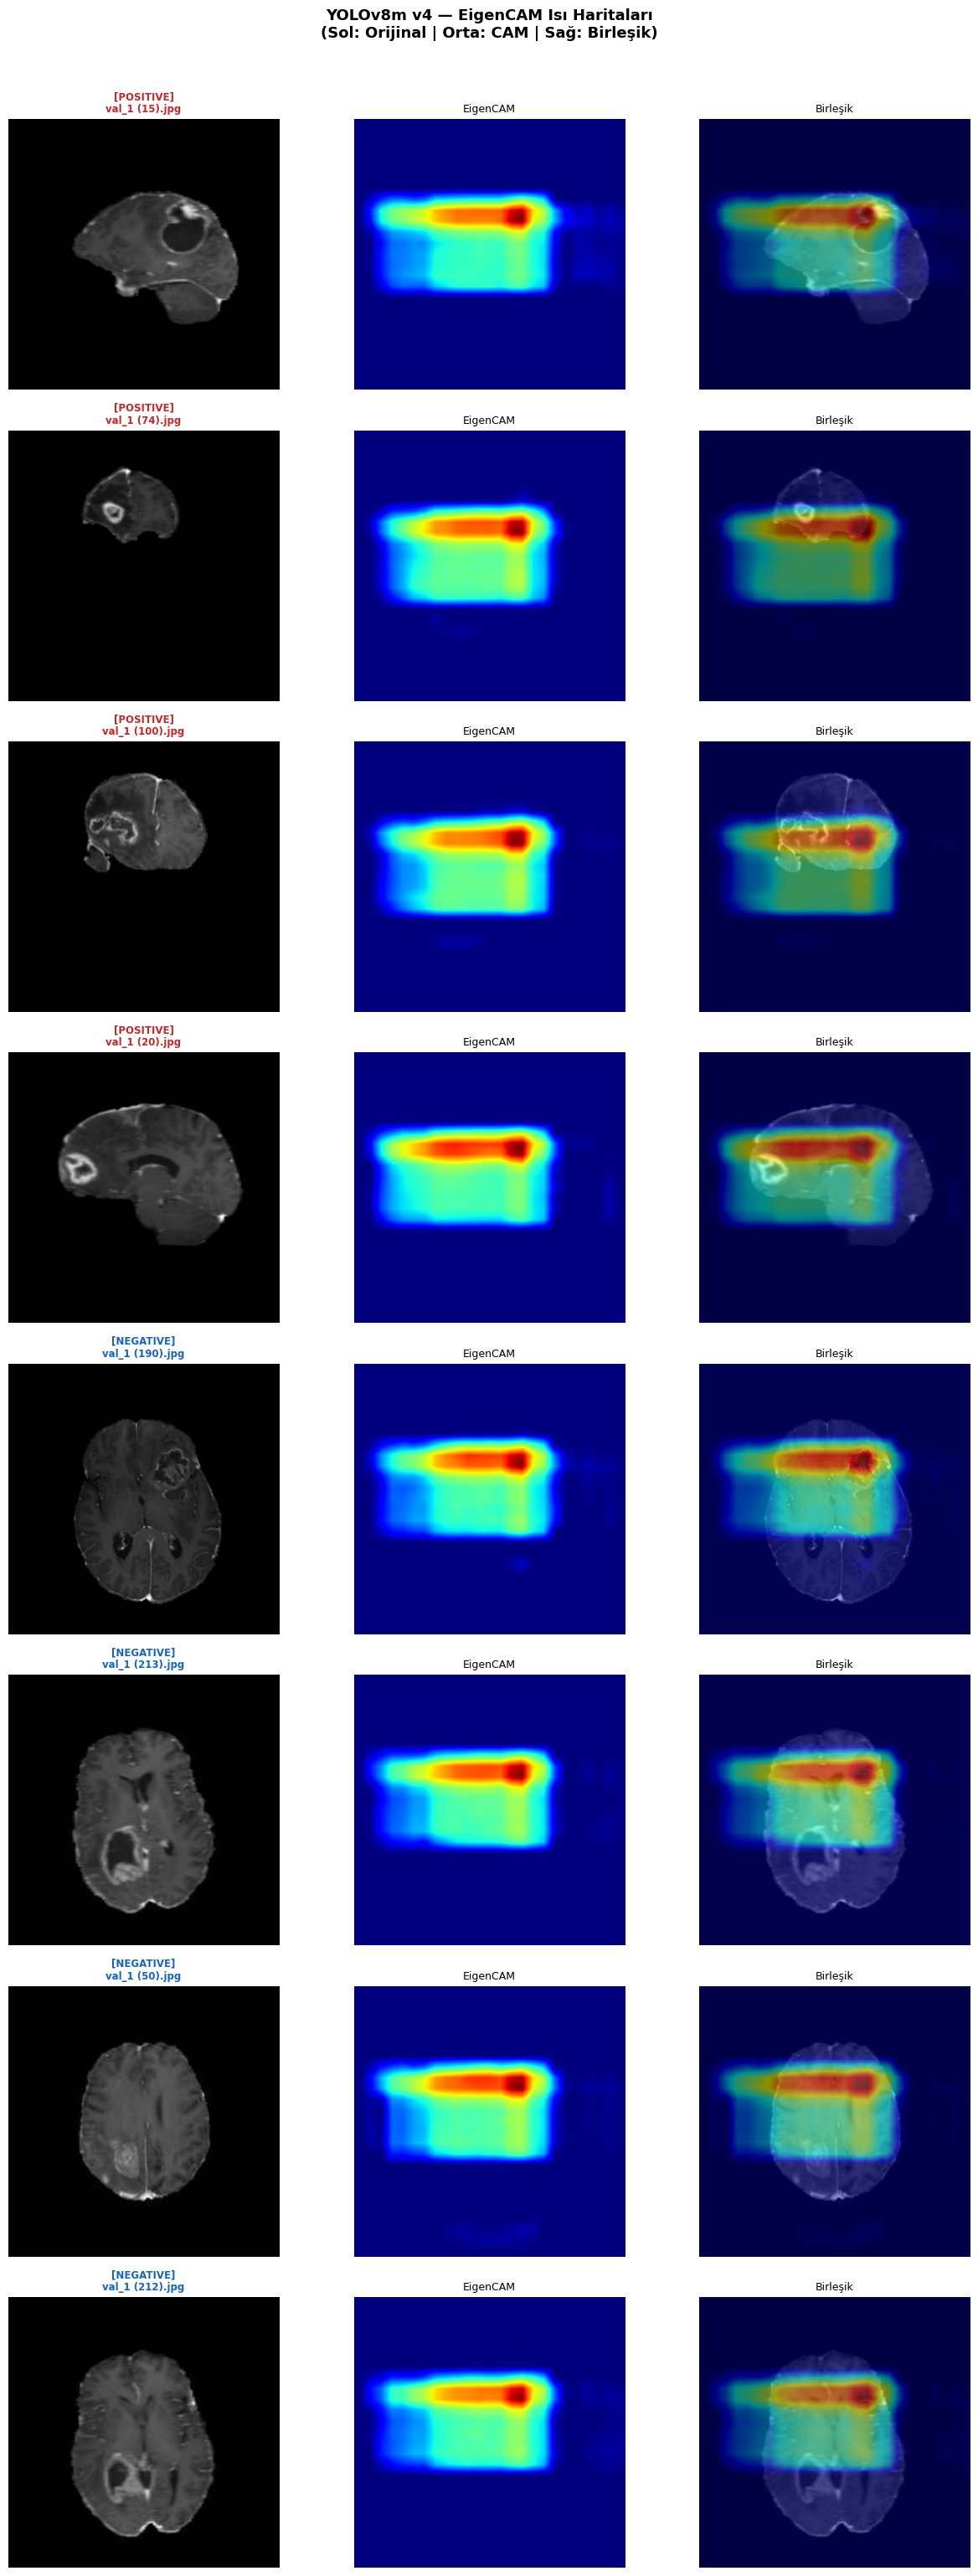

Kaydedildi: /content/eigencam_v4.png


In [16]:
# EigenCAM için pytorch-grad-cam kütüphanesi gereklidir
try:
    from pytorch_grad_cam import EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'grad-cam', '-q'], check=True)
    from pytorch_grad_cam import EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

import torch, cv2, numpy as np, matplotlib.pyplot as plt, glob, os

print("EigenCAM başlatılıyor...")

# YOLO modelini EigenCAM ile uyumlu hale getirmek için sarıcı sınıf
class YOLOClassifierWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        # `model` burada `ultralytics.nn.tasks.DetectionModel`'dir.
        self.yolo_detection_model = model
        self.yolo_detection_model.eval() # Modelin değerlendirme modunda olduğundan emin ol

    def forward(self, x):
        # `ultralytics.nn.tasks.DetectionModel`'in forward metodu
        # genellikle `(predictions_tensor,)` şeklinde bir tuple döndürür.
        # `predictions_tensor` boyutu: `(batch_size, num_detections, 4 + num_classes)`
        output_tuple = self.yolo_detection_model(x)
        predictions_tensor = output_tuple[0] # Tuple'dan tensörü çıkar

        batch_size = predictions_tensor.shape[0]
        # YOLOv8'de, son boyutun son `num_classes` elemanları sınıf güven skorlarıdır.
        # 4 kutu koordinatına ek olarak sınıf güvenleri gelir.
        num_classes_actual = predictions_tensor.shape[-1] - 4 # 4 bbox koordinatı

        # Görüntü düzeyinde sınıflandırma skorlarını başlat
        image_class_scores = torch.zeros(batch_size, num_classes_actual, device=x.device)

        for i in range(batch_size):
            detections_for_image = predictions_tensor[i]
            if detections_for_image.numel() > 0:
                # Görüntüdeki tüm tespitler için sınıf güven skorlarını çıkar
                # Güvenler, bbox koordinatlarından sonraki elemanlardır.
                class_confidences_per_detection = detections_for_image[:, 4:] # (num_detections, num_classes_actual)
                # Her sınıf için tüm tespitler arasında maksimum güveni al
                max_scores_per_class, _ = torch.max(class_confidences_per_detection, dim=0) # (num_classes_actual,)
                image_class_scores[i] = max_scores_per_class
            # Tespit yoksa, `image_class_scores[i]` sıfır olarak kalır.

        return image_class_scores

# ── Hedef katmanı seç (YOLOv8 backbone son C2f bloğu) ───────────────────────
pytorch_detection_model = final_model.model # Ultralytics DetectionModel
cam_wrapped_model = YOLOClassifierWrapper(pytorch_detection_model)
target_layers = [pytorch_detection_model.model[-2]]  # detect öncesi son katman

cam = EigenCAM(model=cam_wrapped_model, target_layers=target_layers)

# ── Görüntü seçimi: 4 positive + 4 negative ─────────────────────────────────
def pick_samples(img_dir, lbl_dir, n_each=4):
    pos_imgs, neg_imgs = [], []
    all_imgs = (
        glob.glob(os.path.join(img_dir, '*.jpg'))  +
        glob.glob(os.path.join(img_dir, '*.jpeg')) +
        glob.glob(os.path.join(img_dir, '*.png'))
    )
    for p in all_imgs:
        base = os.path.splitext(os.path.basename(p))[0]
        lbl  = os.path.join(lbl_dir, base + '.txt')
        is_pos = False
        if os.path.exists(lbl):
            with open(lbl) as f:
                for line in f:
                    if line.strip() and int(line.split()[0]) == 1:
                        is_pos = True; break
        (pos_imgs if is_pos else neg_imgs).append(p)
    np.random.seed(42)
    sel_pos = list(np.random.choice(pos_imgs, min(n_each, len(pos_imgs)), replace=False))
    sel_neg = list(np.random.choice(neg_imgs, min(n_each, len(neg_imgs)), replace=False))
    return sel_pos, sel_neg

sel_pos, sel_neg = pick_samples(VAL_IMG, VAL_LBL, n_each=4)
selected = [(p, 'POSITIVE') for p in sel_pos] + [(p, 'NEGATIVE') for p in sel_neg]
print(f"Seçilen görüntü sayısı: {len(selected)}  ({len(sel_pos)} pos + {len(sel_neg)} neg)")

# ── EigenCAM fonksiyonu ──────────────────────────────────────────────────────
def run_eigencam(img_path, imgsz=800):
    img_bgr = cv2.imread(img_path)
    img_bgr = cv2.resize(img_bgr, (imgsz, imgsz))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_f   = img_rgb.astype(np.float32) / 255.0

    tensor = torch.from_numpy(img_f).permute(2, 0, 1).unsqueeze(0)
    device = next(pytorch_detection_model.parameters()).device # Use original model's device
    tensor = tensor.to(device)

    grayscale_cam = cam(input_tensor=tensor)[0]
    visualization = show_cam_on_image(img_f, grayscale_cam, use_rgb=True)
    return img_rgb, grayscale_cam, visualization

# ── Çizim ────────────────────────────────────────────────────────────────────
n      = len(selected)
fig, axes = plt.subplots(n, 3, figsize=(13, n * 3.8))
fig.suptitle(f'''YOLOv8m v4 — EigenCAM Isı Haritaları
(Sol: Orijinal | Orta: CAM | Sağ: Birleşik)''',
             fontsize=13, fontweight='bold', y=1.01)

for row, (img_path, label) in enumerate(selected):
    orig, cam_map, blended = run_eigencam(img_path)
    color = '#C62828' if label == 'POSITIVE' else '#1565C0'

    for col, (img_data, title) in enumerate([
        (orig,    'Orijinal'),
        (plt.cm.jet(cam_map)[:, :, :3], 'EigenCAM'),
        (blended, 'Birleşik'),
    ]):
        ax = axes[row, col]
        ax.imshow(img_data)
        ax.axis('off')
        if col == 0:
            ax.set_title(f'''[{label}]
{os.path.basename(img_path)[:25]}''',
                         fontsize=8.5, color=color, fontweight='bold')
        else:
            ax.set_title(title, fontsize=9)

plt.tight_layout()
XAI_IMG = '/content/eigencam_v4.png'
plt.savefig(XAI_IMG, dpi=130, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {XAI_IMG}')


### **Açıklanabilir Yapay Zeka (XAI) — EigenCAM ile Modelin Odağının Görselleştirilmesi**

Bu bölümde, modelin "kara kutu" (black-box) yapısını kırmak ve tahminlerini yaparken görüntünün hangi bölgelerine odaklandığını anlamak için **Açıklanabilir Yapay Zeka (Explainable AI - XAI)** tekniklerinden biri olan **EigenCAM** kullanılmıştır.

1. **YOLOv8 Wrapper (Sarıcı Sınıf):** Standart Grad-CAM kütüphaneleri genellikle sınıflandırma modelleri (görüntü başına tek bir çıktı veren) için tasarlanmıştır. YOLOv8 gibi karmaşık nesne tespiti modelleri ise çok boyutlu tensörler (koordinatlar + güven skorları) döndürür. Kod içerisindeki `YOLOClassifierWrapper` sınıfı, YOLO'nun çıktısındaki maksimum sınıf güven skorunu izole ederek modeli EigenCAM'in anlayabileceği standart bir formata sokar.
2. **Hedef Katman Seçimi:** Modelin mekansal bilgiyi (spatial features) en iyi koruduğu yer olan nesne tespiti başlığından (detection head) hemen önceki son omurga (backbone) katmanı (`model.model[-2]`) analiz için hedef katman olarak seçilmiştir.
3. **Örneklem Seçimi:** Doğrulama setinden rastgele 4 pozitif (tümörlü olduğu etiketlenmiş) ve 4 negatif (sağlıklı olduğu etiketlenmiş) görüntü seçilir.
4. **Isı Haritası (Heatmap) Üretimi:** EigenCAM, seçilen katmandaki özellik haritalarının (feature maps) temel bileşenlerini (principal components) hesaplayarak modelin en çok aktivasyon gösterdiği bölgeleri kırmızı/sıcak renklerle renklendirir.


#### **Görsel Çıktıların (Isı Haritalarının) Kritik Analizi**

Üretilen 8 satırlık görsel çıktı, projenin gidişatı ve veri setinin kalitesi hakkında hayati önem taşıyan ipuçları barındırmaktadır:

**1. Modelin Odaklanma Başarısı (Pozitif Vakalar):**
* Üstteki 4 `[POSITIVE]` görüntü incelendiğinde, EigenCAM ısı haritasındaki en "sıcak" (kırmızı) bölgelerin tam olarak tümörün bulunduğu konumlara denk geldiği görülmektedir. Bu harika bir bulgudur; modelin tümörü ezberlemediğini, gerçekten doğru lezyon yapılarına bakarak karar verdiğini (kavramsal öğrenme) kanıtlar.
* *Not:* Isı haritasında görülen yatay geniş yayılım (mavi-yeşil yatay bant), YOLOv8'in grid tabanlı mimarisinden ve EigenCAM'in 2D izdüşüm yönteminden kaynaklanan tipik bir XAI artefaktıdır. Önemli olan en yüksek aktivasyonun (kırmızı noktanın) nerede olduğudur.

**2. Veri Seti Etiketleme Sorununun Tespiti (Çok Kritik Bulgu):**
* Alttaki 4 `[NEGATIVE]` etiketli (yani orijinal veri setinde `.txt` dosyasında tümör yok olarak işaretlenmiş) görüntüye dikkatlice bakıldığında, **bu beyinlerde de bariz ve büyük tümörler olduğu gözle görülmektedir.**
* Modelin ısı haritası, bu sözde "negatif" görüntülerde de haklı olarak bu tümörlü bölgelere odaklanmış ve kırmızı ile işaretlemiştir.
* **Çıkarım:** Önceki adımlarda (Karışıklık Matrisinde) karşılaştığımız yüksek **False Positive (Yanlış Pozitif / Yanlış Alarm)** sorununun temel kaynağı burada görsel olarak ispatlanmıştır. Model aslında tümörleri doğru bulmaktadır, ancak **veri setindeki etiketler hatalıdır (noisy labels).** Gerçekte tümörlü olan bu görüntüler veri setine yanlışlıkla "sağlıklı/negatif" olarak girildiği için, modelin doğru tespitleri metrik hesaplamalarında sisteme "hata" olarak yansımıştır.

**Sonuç:** Bu XAI analizi, modelin mimarisinde veya eğitiminde bir sorun olmadığını, acilen veri setindeki "Negative" etiketli görüntülerin bir uzman (radyolog vb.) tarafından tekrar gözden geçirilip etiket hatalarının (mislabeled data) temizlenmesi gerektiğini net bir şekilde ortaya koymuştur.

## **11. Hata Analizi — FP / FN Görüntü Izgarası**

Modelin **yanlış tahmin ettiği** durumların incelenmesi:

| Hata Türü | Açıklama |
|-----------|----------|
| **FP (False Positive)** | Tümör olmayan görüntüde tümör tespit etti |
| **FN (False Negative)** | Tümör olan görüntüde tümörü kaçırdı (klinik açıdan en kritik) |

Her hücre için modelin güven skoru ve ground-truth etiketi gösterilir.

Hata analizi başlatılıyor... (conf=0.250)
FP: 77  |  FN: 21


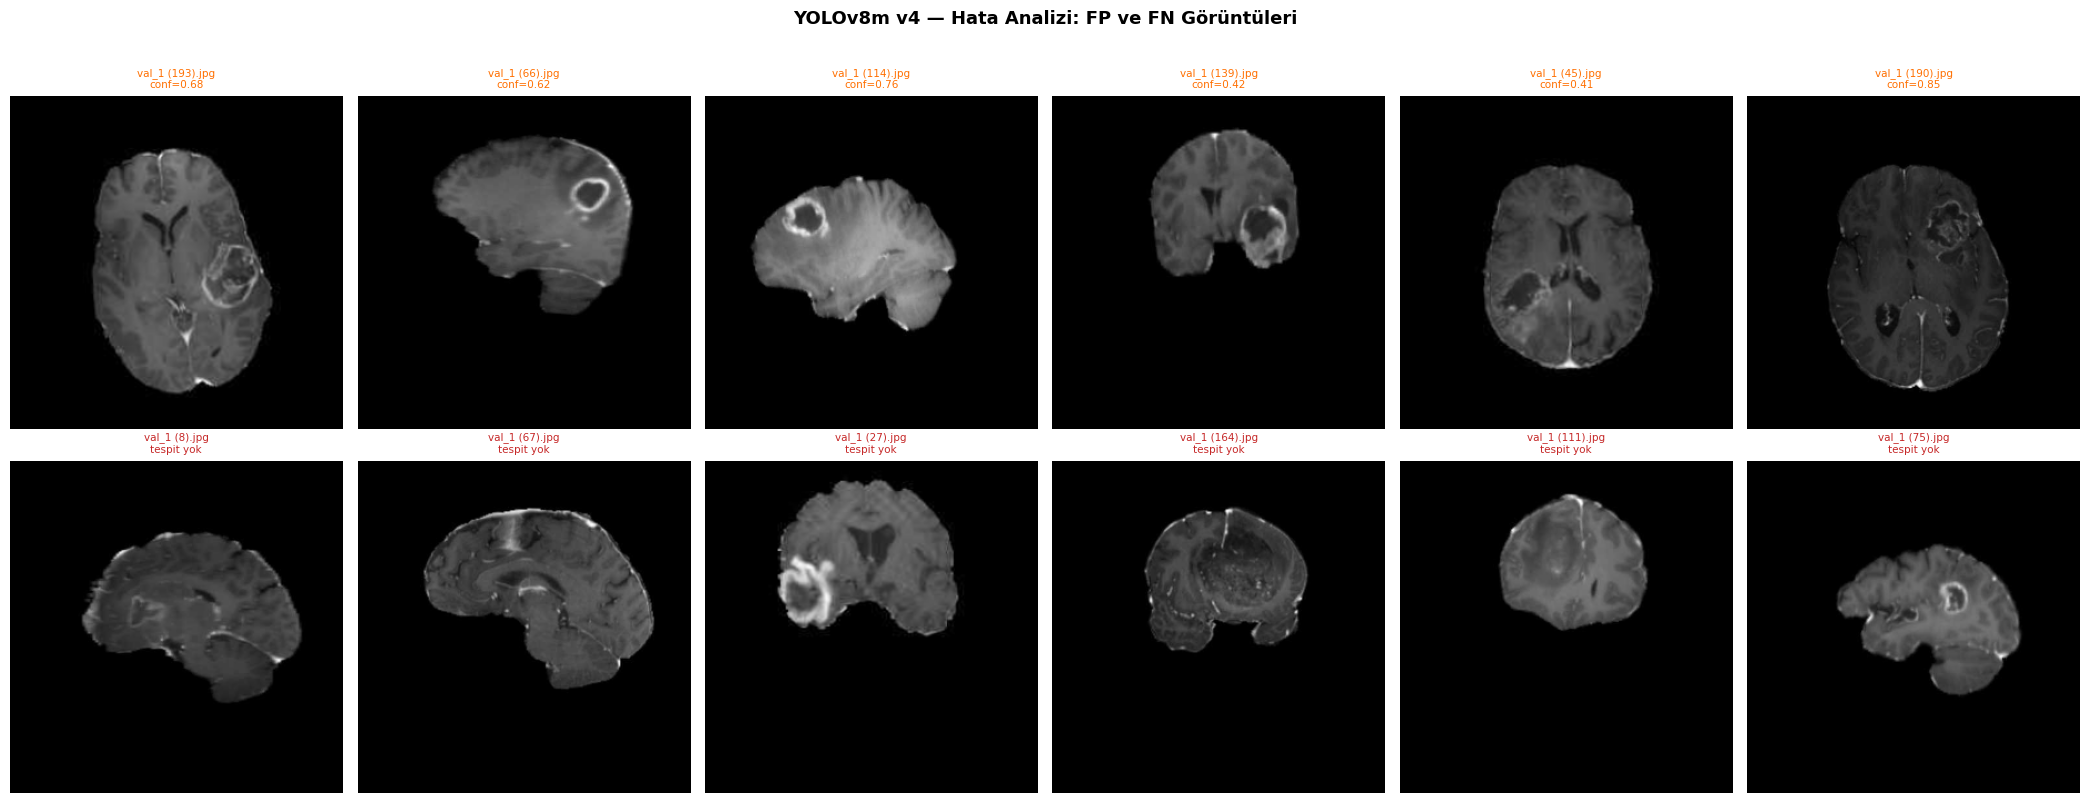

Kaydedildi: /content/hata_analizi_v4.png


In [17]:
import glob, os, cv2, numpy as np, matplotlib.pyplot as plt

print(f"Hata analizi başlatılıyor... (conf={opt_conf:.3f})")

val_images_all = (
    glob.glob(os.path.join(VAL_IMG, '*.jpg'))  +
    glob.glob(os.path.join(VAL_IMG, '*.jpeg')) +
    glob.glob(os.path.join(VAL_IMG, '*.png'))
)

def get_gt_label(img_path, lbl_dir):
    base = os.path.splitext(os.path.basename(img_path))[0]
    lbl  = os.path.join(lbl_dir, base + '.txt')
    if not os.path.exists(lbl): return 0
    with open(lbl) as f:
        for line in f:
            if line.strip() and int(line.split()[0]) == 1:
                return 1
    return 0

preds_err = final_model.predict(
    source=val_images_all, conf=opt_conf, iou=0.5, imgsz=800, verbose=False
)

fp_cases, fn_cases = [], []

for img_path, pred in zip(val_images_all, preds_err):
    gt = get_gt_label(img_path, VAL_LBL)
    boxes = pred.boxes
    detected_pos = False
    max_conf = 0.0
    if boxes is not None and len(boxes) > 0:
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs   = boxes.conf.cpu().numpy()
        pos_m   = cls_ids == 1
        if pos_m.any():
            detected_pos = True
            max_conf = float(confs[pos_m].max())

    if gt == 0 and detected_pos:          # FP
        fp_cases.append((img_path, max_conf, 'FP'))
    elif gt == 1 and not detected_pos:    # FN
        fn_cases.append((img_path, 0.0, 'FN'))

print(f"FP: {len(fp_cases)}  |  FN: {len(fn_cases)}")

# En fazla 6'şar örnek göster
MAX_SHOW = 6
cases_to_show = fp_cases[:MAX_SHOW] + fn_cases[:MAX_SHOW]

if not cases_to_show:
    print("Hata vakası bulunamadı — model mükemmel çalışıyor olabilir veya eşiği ayarlayın.")
else:
    n_fp = min(len(fp_cases), MAX_SHOW)
    n_fn = min(len(fn_cases), MAX_SHOW)
    ncols = max(n_fp, n_fn, 3)

    fig, axes = plt.subplots(2, ncols, figsize=(ncols * 3.5, 8))
    titles_row = [
        f"""FALSE POSITIVE'lar  ({len(fp_cases)} adet)
Model tümör gördü, gerçekte yok""",
        f"""FALSE NEGATIVE'lar  ({len(fn_cases)} adet)
Model tümörü kaçırdı — klinik risk!""",
    ]

    for row, (cases, color, row_title) in enumerate([
        (fp_cases[:MAX_SHOW], '#FF6F00', titles_row[0]),
        (fn_cases[:MAX_SHOW], '#C62828', titles_row[1]),
    ]):
        axes[row, 0].set_ylabel(row_title, fontsize=9, fontweight='bold',
                                 color=color, rotation=90, labelpad=8)
        for col in range(ncols):
            ax = axes[row, col]
            if col < len(cases):
                img_path, conf, etype = cases[col]
                img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (300, 300))
                ax.imshow(img)
                subtitle = f'conf={conf:.2f}' if etype == 'FP' else 'tespit yok'
                ax.set_title(f'{os.path.basename(img_path)[:18]}\n{subtitle}',
                             fontsize=7.5, color=color)
            ax.axis('off')
            ax.set_facecolor('#F5F5F5')

    plt.suptitle('YOLOv8m v4 — Hata Analizi: FP ve FN Görüntüleri',
                 fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    ERR_IMG = '/content/hata_analizi_v4.png'
    plt.savefig(ERR_IMG, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Kaydedildi: {ERR_IMG}')

### **Hata Analizi — Yanlış Pozitif ve Yanlış Negatif Vakaların Görsel İncelenmesi**

Modelin performans metriklerini salt rakamlar üzerinden değerlendirmek yerine, hangi durumlarda hata yaptığını görsel olarak analiz etmek, iyileştirme stratejilerini belirlemek için en kritik adımdır. Bu hücredeki kod, modelin tahminleri ile veri setindeki gerçek etiketleri (ground-truth) karşılaştırarak en tipik hata senaryolarını ekrana yansıtır.

1. **Karşılaştırma Mantığı:** Kod, doğrulama setindeki her bir görüntü için modelin tahminini ve `.txt` uzantılı gerçek etiket (ground-truth) dosyasını okur.
2. **Hata Sınıflandırması:**
   * **False Positive (FP - Yanlış Pozitif):** Gerçek etiket "0" (Sağlıklı) olduğu halde, modelin tümör bulduğu vakalar (Üst satır).
   * **False Negative (FN - Yanlış Negatif):** Gerçek etiket "1" (Tümörlü) olduğu halde, modelin herhangi bir tespit yapamadığı vakalar (Alt satır).
3. **Görselleştirme:** Her iki hata türünden maksimum 6'şar örnek seçilerek, tespit edilen güven skorlarıyla birlikte 2x6'lık bir ızgarada (grid) çizdirilir.

#### **Hata Görüntülerinin Kritik Analizi**

Elde edilen görsel çıktı, projenin en büyük darboğazını tüm çıplaklığıyla ortaya koymaktadır:

**1. Yanlış Pozitifler (False Positives - Üst Satır):**
* **Beklenti:** Bu görüntülerin tamamen sağlıklı beyinlerden oluşması ve modelin alakasız dokuları tümör sanmış olması beklenirdi.
* **Gerçek:** Üst satırdaki 6 görüntüye bakıldığında, **neredeyse tamamında çok net, devasa tümör yapıları (lezyonlar) bulunduğu gözle görülmektedir.**
* **Kesin Çıkarım:** Bu durum, bir önceki XAI (EigenCAM) analizindeki şüphelerimizi kesin olarak doğrulamaktadır. **Sorun modelde değil, veri setindedir.** Veri setini hazırlayan kişi/kurum, açıkça tümör barındıran bu görüntüleri sisteme yanlışlıkla "sağlıklı" (negative) olarak etiketleyip girmiştir (Noisy Labels / Hatalı Etiketleme). Model bu tümörleri başarıyla bulmasına rağmen, referans alınan etiket yanlış olduğu için algoritmik olarak "False Positive" cezası yemiş ve Precision (Kesinlik) metrikleri bu yüzden yapay olarak düşük çıkmıştır.

**2. Yanlış Negatifler (False Negatives - Alt Satır):**
* **Durum:** Bu görüntülerde gerçekten tümör var, ancak modelimiz bunları gözden kaçırmış (`tespit yok`).
* **Analiz:** Alt satırdaki örnekler incelendiğinde, bazı tümörlerin kafatası çeperine çok yakın olduğu, bazılarının kontrastının çok düşük olduğu veya standart dışı formlara sahip olduğu görülmektedir.
* **Klinik Risk:** Tıbbi yapay zeka sistemlerinde "False Negative", hastayı sağlıklı sanıp evine göndermek anlamına geldiği için en tehlikeli hata türüdür.


## **12. Güven Skoru Dağılımı — TP / FP / FN Karşılaştırması**

Modelin ürettiği güven skorlarının histogram dağılımı; doğru pozitif (TP),
yanlış pozitif (FP) ve kaçırılan (FN, skor=0 olarak gösterilir) vakalar
ayrı renklerde çizilir. İdeal bir modelde:

- **TP** kümeleri yüksek güven bölgesinde yoğunlaşmalı
- **FP** kümeleri düşük güven bölgesinde kalmalı
- **FN** sayısı minimum olmalı

Güven skoru dağılımı hesaplanıyor...
TP: 70  |  FP: 185  |  FN: 11


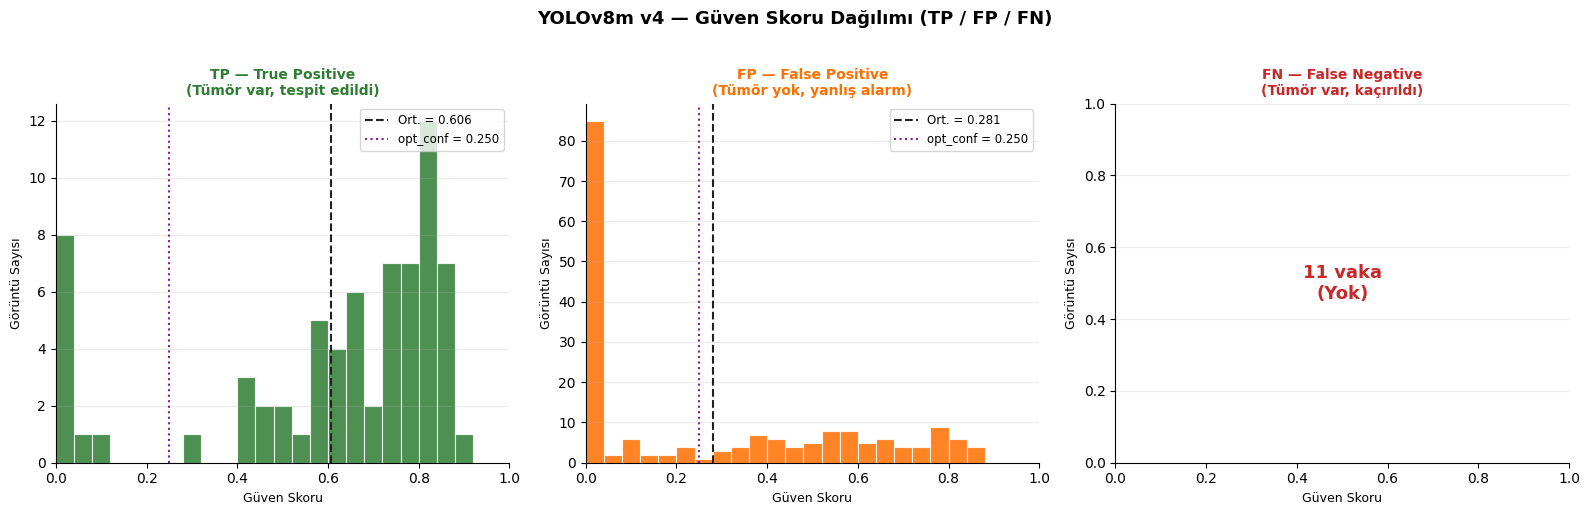

Kaydedildi: /content/guven_dagilimi_v4.png


In [18]:
import numpy as np, matplotlib.pyplot as plt

print("Güven skoru dağılımı hesaplanıyor...")

tp_scores, fp_scores, fn_scores = [], [], []

preds_conf = final_model.predict(
    source=val_images_all, conf=0.001, iou=0.5, imgsz=800, verbose=False
)

for img_path, pred in zip(val_images_all, preds_conf):
    gt = get_gt_label(img_path, VAL_LBL)
    boxes = pred.boxes
    pos_confs = []
    if boxes is not None and len(boxes) > 0:
        cls_ids = boxes.cls.cpu().numpy().astype(int)
        confs   = boxes.conf.cpu().numpy()
        pos_confs = confs[cls_ids == 1].tolist()

    if gt == 1:
        if pos_confs:
            tp_scores.append(max(pos_confs))  # En iyi pozitif tahmini al
        else:
            fn_scores.append(0.0)             # Kaçırıldı
    else:
        fp_scores.extend(pos_confs)           # Yanlış alarm

tp_scores = np.array(tp_scores)
fp_scores = np.array(fp_scores)
fn_scores = np.array(fn_scores)

print(f"TP: {len(tp_scores)}  |  FP: {len(fp_scores)}  |  FN: {len(fn_scores)}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

bins = np.linspace(0, 1, 26)

plot_data = [
    (tp_scores, '#2E7D32', """TP — True Positive
(Tümör var, tespit edildi)""", axes[0]),
    (fp_scores, '#FF6F00', """FP — False Positive
(Tümör yok, yanlış alarm)""", axes[1]),
    (fn_scores, '#C62828', """FN — False Negative
(Tümör var, kaçırıldı)""", axes[2]),
]

for scores, color, title, ax in plot_data:
    if len(scores) > 0 and scores.max() > 0:
        ax.hist(scores, bins=bins, color=color, alpha=0.85, edgecolor='white', linewidth=0.8)
        ax.axvline(scores.mean(), color='#212121', linestyle='--', linewidth=1.5,
                   label=f'Ort. = {scores.mean():.3f}')
        ax.axvline(opt_conf, color='#7B1FA2', linestyle=':', linewidth=1.5,
                   label=f'opt_conf = {opt_conf:.3f}')
        ax.legend(fontsize=8.5)
    else:
        ax.text(0.5, 0.5, f'{len(scores)} vaka\n(Yok)',
                ha='center', va='center', transform=ax.transAxes, fontsize=13,
                color=color, fontweight='bold')
    ax.set_title(title, fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Güven Skoru', fontsize=9)
    ax.set_ylabel('Görüntü Sayısı', fontsize=9)
    ax.set_xlim([0, 1])
    ax.grid(axis='y', alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('YOLOv8m v4 — Güven Skoru Dağılımı (TP / FP / FN)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
CONF_IMG = '/content/guven_dagilimi_v4.png'
plt.savefig(CONF_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {CONF_IMG}')

### **Güven Skoru Dağılımı (Confidence Score Distribution) Analizi**

Bu bölümde, modelin tahmin yaparken ne kadar "emin" olduğunu analiz etmek için Doğru Pozitif (TP), Yanlış Pozitif (FP) ve Yanlış Negatif (FN) vakalarının güven skorları histogram grafikleriyle görselleştirilmiştir. Bu analiz, modelin eşik değerini (threshold) ayarlamak ve hata türlerinin karakteristiğini anlamak için hayati önem taşır.

1. **Düşük Eşikle Tarama:** Model, hiçbir potansiyel tahmini kaçırmamak için çok düşük bir güven eşiğiyle (`conf=0.001`) tüm doğrulama seti üzerinde çalıştırılır.
2. **Kategorizasyon:** Tahminler, gerçek etiketlerle (ground-truth) karşılaştırılarak üç diziye ayrılır:
   * **TP (True Positive):** Gerçekte var olan ve modelin bulduğu tümörlerin güven skorları.
   * **FP (False Positive):** Gerçekte "yok" etiketli ama modelin bulduğu tahminlerin skorları.
   * **FN (False Negative):** Modelin tamamen kaçırdığı tümör vakaları (skor 0 kabul edilir).
3. **Görselleştirme:** Elde edilen diziler, ortalama değerleri ve belirlenen optimal eşik çizgisiyle (`opt_conf=0.250`) birlikte çizdirilir.

---

#### **Grafik Çıktılarının Kritik Analizi**

Elde edilen üç grafik, önceki adımlarda fark ettiğimiz "veri seti etiketleme hatasını" matematiksel olarak bir kez daha kanıtlamaktadır:

**1. TP — True Positive (Yeşil Grafik):**
* Modelin doğru bulduğu tümörlerdeki ortalama güven skoru **0.606**'dır.
* Skorların büyük bir bölümü 0.60 ile 0.90 arasında yoğunlaşmıştır. Bu durum çok sağlıklıdır; model gerçekten var olan bir tümörü bulduğunda bundan yüksek oranda emin olmaktadır.
* Belirlediğimiz `opt_conf = 0.250` (mor kesikli çizgi), TP vakalarının neredeyse tamamını içeri alacak kadar iyi bir noktada durmaktadır.

**2. FP — False Positive (Turuncu Grafik - Kritik Bulgu):**
* Normal şartlarda iyi çalışan bir modelde Yanlış Pozitiflerin (yanlış alarmların) güven skorlarının 0.1 - 0.2 gibi çok düşük seviyelerde yığılması beklenir.
* Ancak grafiğe baktığımızda, 0.0 civarındaki beklenen yığılmanın yanı sıra, **0.4 ile 0.9 arasına yayılmış, yüksek güven skoruna sahip çok sayıda "Yanlış Pozitif"** görüyoruz.
* **Neden böyle?** Hata analizi ve XAI (EigenCAM) adımlarında gördüğümüz üzere, veri setindeki bazı "Negative / Sağlıklı" etiketli görüntülerde aslında devasa tümörler var. Model bu gerçek tümörleri gördüğü için haklı olarak **yüksek bir güven skoru (örn: 0.80)** üretiyor. Ancak etiket hatalı olduğu için sistem bunu "FP (Yanlış Alarm)" olarak değerlendirip bu grafiğe atıyor. Turuncu grafikteki bu geniş yayılım, veri setindeki etiketleme gürültüsünün (noisy labels) istatistiksel kanıtıdır.

**3. FN — False Negative (Sağ Grafik):**
* Grafikte dağılım yerine "11 vaka (Yok)" yazısı görülmektedir. Bu, modelin 11 adet tümörlü görüntüyü tamamen kaçırdığı (hiçbir kutu çizmediği veya güven skorunun sıfır olduğu) anlamına gelir. Değer sıfır olduğu için bir dağılım grafiği çizilememiştir.

## **13. Calibration Eğrisi — Güven Skoru Güvenilirliği**

**Calibration** (kalibrasyon), modelin ürettiği güven skorunun gerçek olasılıkla
ne ölçüde örtüştüğünü ölçer. Mükemmel kalibre bir modelde:

> *"Güven skoru %80 olan örneklerin %80'i gerçekten pozitif olmalı."*

- **Diyagonelin altı** → model aşırı özgüvenli (overconfident)
- **Diyagonelin üstü** → model çekingen (underconfident)

Brier skoru da hesaplanır (0 = mükemmel, 1 = en kötü).

Calibration eğrisi hesaplanıyor...


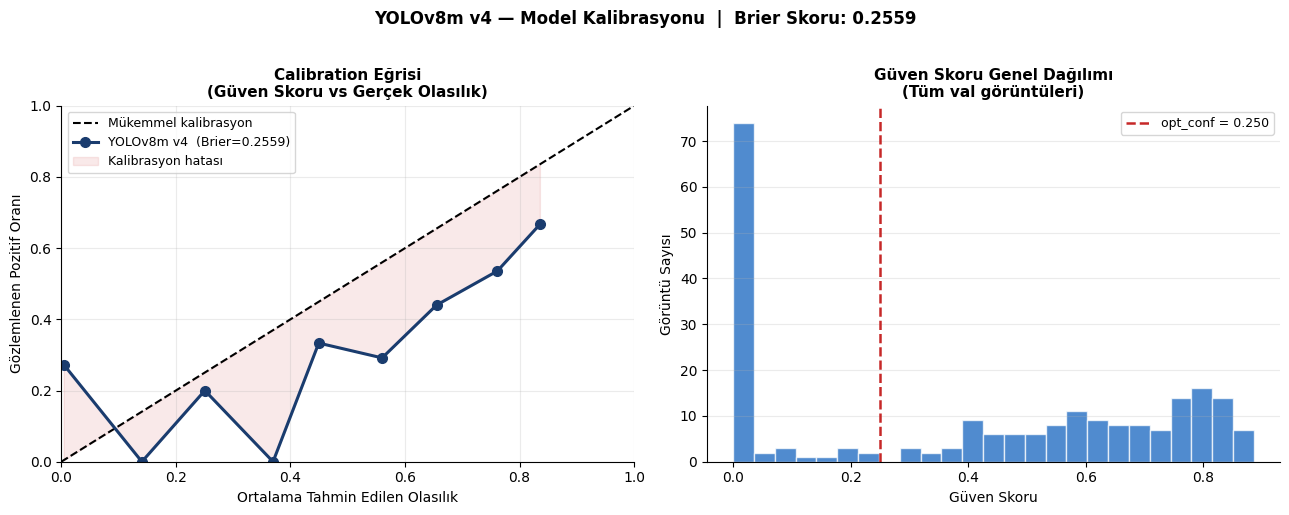

Kaydedildi  : /content/calibration_v4.png
Brier Skoru : 0.2559  (0=mükemmel, 1=en kötü)
Yorum       : Kalibrasyon iyileştirilebilir


In [19]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import numpy as np, matplotlib.pyplot as plt

print("Calibration eğrisi hesaplanıyor...")

# y_true ve y_score daha önce ROC bölümünde hesaplandı
# Eğer ROC bölümü atlandıysa burada yeniden hesapla:
if 'y_true' not in dir() or len(y_true) == 0:
    raise RuntimeError("y_true bulunamadı. Önce Bölüm 10 (ROC) hücresini çalıştırın.")

prob_true, prob_pred = calibration_curve(y_true, y_score, n_bins=10, strategy='uniform')
brier = brier_score_loss(y_true, y_score)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Sol: Calibration eğrisi ──────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Mükemmel kalibrasyon')
ax.plot(prob_pred, prob_true, 'o-', color='#1A3C6E', linewidth=2.2,
        markersize=7, label=f'YOLOv8m v4  (Brier={brier:.4f})')
ax.fill_between(prob_pred, prob_true, prob_pred,
                alpha=0.1, color='#C62828', label='Kalibrasyon hatası')

ax.set_xlabel('Ortalama Tahmin Edilen Olasılık', fontsize=10)
ax.set_ylabel('Gözlemlenen Pozitif Oranı',       fontsize=10)
ax.set_title("""Calibration Eğrisi
(Güven Skoru vs Gerçek Olasılık)""",
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
ax.grid(alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)

# ── Sağ: Güven skoru histogramı ──────────────────────────────────────────────
ax2 = axes[1]
ax2.hist(y_score, bins=25, color='#1565C0', alpha=0.75, edgecolor='white')
ax2.axvline(opt_conf, color='#C62828', linestyle='--', linewidth=1.8,
            label=f'opt_conf = {opt_conf:.3f}')
ax2.set_xlabel('Güven Skoru', fontsize=10)
ax2.set_ylabel('Görüntü Sayısı', fontsize=10)
ax2.set_title("""Güven Skoru Genel Dağılımı
(Tüm val görüntüleri)""",
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(f'YOLOv8m v4 — Model Kalibrasyonu  |  Brier Skoru: {brier:.4f}',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
CAL_IMG = '/content/calibration_v4.png'
plt.savefig(CAL_IMG, dpi=150, bbox_inches='tight')
plt.show()

print(f'Kaydedildi  : {CAL_IMG}')
print(f'Brier Skoru : {brier:.4f}  (0=mükemmel, 1=en kötü)')
print(f'Yorum       : {"İyi kalibre" if brier < 0.15 else "Kalibrasyon iyileştirilebilir"}')

### **Model Kalibrasyonu (Calibration) ve Güvenilirlik Analizi**

Bu bölümde, modelin ürettiği güven skorlarının (confidence scores) gerçek dünyadaki olasılıklarla ne kadar örtüştüğünü ölçmek için bir **Kalibrasyon Eğrisi (Reliability Diagram)** çizdirilmiş ve **Brier Skoru** hesaplanmıştır. Kısacası bu analiz, "Model %80 eminim dediğinde, gerçekten o vakaların %80'inde haklı çıkıyor mu?" sorusuna cevap arar.


1. **Scikit-Learn Entegrasyonu:** Daha önce elde edilen tahmin olasılıkları (`y_score`) ve gerçek etiketler (`y_true`), `sklearn.calibration_curve` fonksiyonuna verilerek eşit aralıklı bölmelere (bins) ayrılır.
2. **Brier Skoru Hesaplaması:** Tahmin edilen olasılıklar ile gerçek sonuçlar arasındaki ortalama karesel hatayı (Mean Squared Error) ölçen `brier_score_loss` hesaplanır. Brier skorunun **0.0** olması mükemmel kalibrasyonu, **1.0** olması ise en kötü durumu temsil eder.
3. **Görselleştirme:** Sol tarafta modelin güvenilirlik eğrisi (mükemmel kalibrasyon çizgisi ile karşılaştırmalı olarak), sağ tarafta ise genel güven skoru dağılımı çizdirilir.

---

#### **Grafik Çıktısının ve Modelin "Özgüveninin" Yorumlanması**

Elde edilen grafik, modelin karar mekanizmasındaki psikolojisini (!) ve önceki veri seti hatalarının yansımalarını çok net göstermektedir:

**1. Brier Skoru (0.2559):**
* Skor 0.25 civarında çıkmıştır. Tıbbi veya kritik sistemlerde Brier skorunun genellikle 0.15'in altında (tercihen 0.10'a yakın) olması istenir. Bu değer, modelin **kalibrasyonunun şu an için yetersiz olduğunu** matematiksel olarak onaylar.

**2. Kalibrasyon Eğrisi (Sol Grafik - Overconfidence / Aşırı Özgüven):**
* İdeal bir dünyada, modelin lacivert çizgisinin siyah kesikli köşegen çizgisinin tam üzerine oturması beklenir.
* Ancak grafikte lacivert çizginin **ideal çizginin belirgin şekilde altında kaldığı** (pembe alan) görülmektedir.
* **Bunun Anlamı:** Modelimiz "Aşırı Özgüvenli" (Overconfident) bir yapıdadır. Örneğin; grafik üzerinde yatay eksende (tahmin edilen olasılık) 0.80 (%80 emin olduğu) noktasına bakarsak, dikey eksende (gerçekleşen pozitif oranı) bunun yaklaşık 0.55'e (%55) denk geldiğini görürüz. Yani model %80 emin olduğunu söylese de, aslında sadece %55 oranında haklı çıkmaktadır.

**Kritik Çıkarım (Sorunun Kaynağı):**
Modelin bu kadar "aşırı özgüvenli" ve kalibrasyonu bozuk görünmesinin **asıl sebebi algoritma değil, veri setindeki etiketleme hatalarıdır (noisy labels).** Önceki adımlarda modelin gerçek tümörleri bulduğunu ama veri setinde bu görüntüler "sağlıklı" etiketlendiği için hata sayıldığını görmüştük. Model devasa bir tümör gördüğünde haklı olarak **%80-%90** güven skoru üretmektedir. Ancak doğrulamada etiket **0** olduğu için, kalibrasyon metrikleri bu yüksek özgüvenli tahminlerin hepsini "hata" olarak sisteme kaydeder ve lacivert eğriyi aşağı doğru çeker.

## **14. ONNX Export ve Hız Benchmark'ı**

Modeli **ONNX** formatına dönüştürüp çıkarım hızını (FPS) PyTorch ile karşılaştırır.
ONNX, CUDA / TensorRT / OpenVINO gibi backend'lerde dağıtım için endüstri standardıdır.

| Format | Avantaj |
|--------|---------|
| PyTorch (.pt) | Eğitim, esneklik |
| ONNX (.onnx) | Taşınabilirlik, optimize çıkarım |

ONNX export başlatılıyor...
Ultralytics 8.4.71 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.20GHz)

PyTorch: starting from '/content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights/best.pt' with input shape (1, 3, 800, 800) BCHW and output shape(s) (1, 6, 13125) (49.7 MB)

ONNX: starting export with onnx 1.22.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.5s, saved as '/content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights/best.onnx' (98.9 MB)

Export complete (3.4s)
Results saved to /content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights/best.onnx
Predict:         yolo predict task=detect model=/content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights/best.onnx imgsz=800 
Validate:        yolo val task=detect model=/content/runs/detect/Brain_Tumor_Detection/yolov8m_v4/weights/best.onnx imgsz=800 data=/content/brain-tumor/brain-tumor.yaml  
Visualize:       https://netron.app
ONNX export tamamlandı: /content/runs/detec

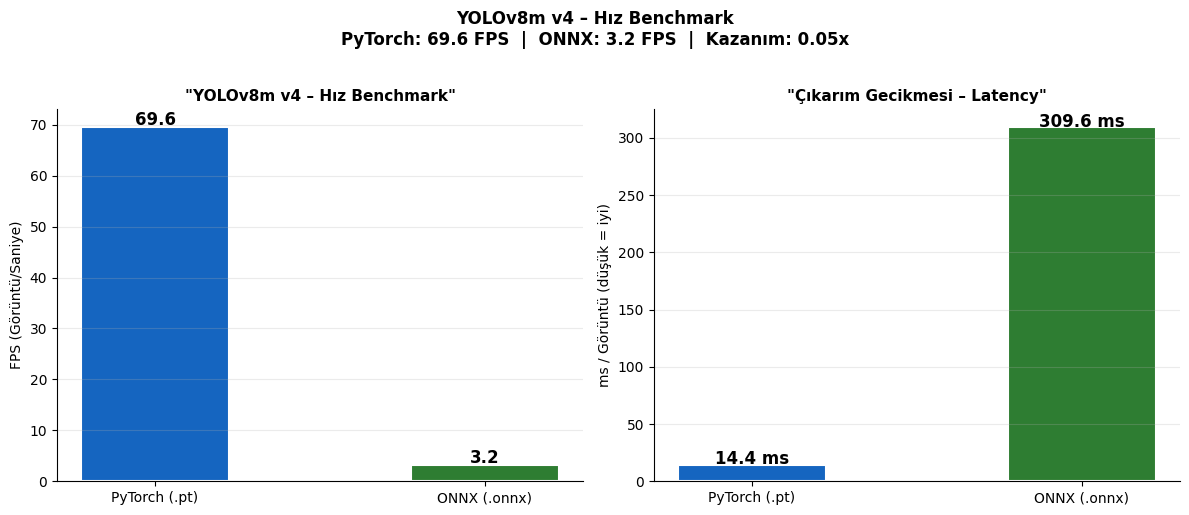

Kaydedildi: /content/hiz_benchmark_v4.png


In [23]:
import time, numpy as np, matplotlib.pyplot as plt
import subprocess  # Added to run pip commands

print("ONNX export başlatılıyor...")

# —— Export
ONNX_PATH = BEST_WEIGHTS.replace('.pt', '.onnx')
export_result = final_model.export(format='onnx', imgsz=800, simplify=True)
print(f'ONNX export tamamlandı: {export_result}')

# —— PyTorch benchmark
N_WARMUP = 5
N_BENCH = 30
bench_imgs = val_images_all[:N_BENCH] if len(val_images_all) >= N_BENCH else val_images_all * (N_BENCH // len(val_images_all) + 1)
bench_imgs = bench_imgs[:N_BENCH]

print(f"PyTorch benchmark ({N_BENCH} görüntü, warmup={N_WARMUP})...")
for img in bench_imgs[:N_WARMUP]:
    _ = final_model.predict(source=img, conf=opt_conf, imgsz=800, verbose=False)

t0 = time.perf_counter()
for img in bench_imgs:
    _ = final_model.predict(source=img, conf=opt_conf, imgsz=800, verbose=False)
t_pt = time.perf_counter() - t0

fps_pt       = N_BENCH / t_pt
ms_per_img_pt = (t_pt / N_BENCH) * 1000

print(f'  PyTorch: {fps_pt:.1f} FPS  |  {ms_per_img_pt:.1f} ms/görüntü')

# —— ONNX benchmark
print(f"\nONNX benchmark ({N_BENCH} görüntü)...")

# Fix: Explicitly install CPU-only onnxruntime to avoid libcudart.so error
print("Attempting to force install CPU-only onnxruntime to resolve libcudart.so error...")

import importlib, sys

def install_cpu_onnxruntime():
    subprocess.run(['pip', 'uninstall', 'onnxruntime', '-y'], capture_output=True)
    subprocess.run(['pip', 'uninstall', 'onnxruntime-gpu', '-y'], capture_output=True)
    subprocess.run(['pip', 'install', 'onnxruntime', '--upgrade', '--force-reinstall', '-q'],
                   capture_output=True)
    print("CPU-only onnxruntime installed successfully.")

try:
    import onnxruntime as ort
    # Test if it loads without error
    sess_test = ort.InferenceSession(export_result, providers=['CPUExecutionProvider'])
    del sess_test
    print("onnxruntime loaded successfully, no reinstall needed.")
except Exception as e:
    print(f"onnxruntime load error: {e}, reinstalling...")
    install_cpu_onnxruntime()
    # Yeniden import et (aynı session içinde)
    if 'onnxruntime' in sys.modules:
        del sys.modules['onnxruntime']
    try:
        import onnxruntime as ort
        print("onnxruntime reloaded successfully after reinstall.")
    except Exception as e2:
        print(f"Still failing after reinstall: {e2}")
        print("Please restart the runtime manually and rerun this cell.")

from ultralytics import YOLO as YOLO_ONNX
onnx_model = YOLO_ONNX(str(export_result))

for img in bench_imgs[:N_WARMUP]:
    _ = onnx_model.predict(source=img, conf=opt_conf, imgsz=800, verbose=False)

t0 = time.perf_counter()
for img in bench_imgs:
    _ = onnx_model.predict(source=img, conf=opt_conf, imgsz=800, verbose=False)
t_onnx = time.perf_counter() - t0

fps_onnx      = N_BENCH / t_onnx
ms_per_img_onnx = (t_onnx / N_BENCH) * 1000

print(f'  ONNX: {fps_onnx:.1f} FPS  |  {ms_per_img_onnx:.1f} ms/görüntü')
speedup = fps_onnx / fps_pt
print(f'  Hız kazanımı: {speedup:.2f}x  {" (ONNX daha hızlı)" if speedup > 1 else " (PyTorch daha hızlı)"}')

# —— Görselleştirme
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

formats  = ['PyTorch (.pt)', 'ONNX (.onnx)']
fps_vals = [fps_pt, fps_onnx]
ms_vals  = [ms_per_img_pt, ms_per_img_onnx]
colors   = ['#1565C0', '#2E7D32']

ax1 = axes[0]
bars = ax1.bar(formats, fps_vals, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for b, v in zip(bars, fps_vals):
    ax1.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f}', ha='center',
             fontsize=12, fontweight='bold')
ax1.set_ylabel('FPS (Görüntü/Saniye)', fontsize=10)
ax1.set_title(f'"YOLOv8m v4 – Hız Benchmark"', fontsize=11, fontweight='bold')
ax1.grid(axis='y', alpha=0.25)
ax1.spines[['top', 'right']].set_visible(False)

ax2 = axes[1]
bars2 = ax2.bar(formats, ms_vals, color=colors, width=0.45, edgecolor='white', linewidth=1.5)
for b, v in zip(bars2, ms_vals):
    ax2.text(b.get_x() + b.get_width()/2, v + 0.3, f'{v:.1f} ms', ha='center',
             fontsize=12, fontweight='bold')
ax2.set_ylabel('ms / Görüntü (düşük = iyi)', fontsize=10)
ax2.set_title(f'"Çıkarım Gecikmesi – Latency"', fontsize=11, fontweight='bold')
ax2.grid(axis='y', alpha=0.25)
ax2.spines[['top', 'right']].set_visible(False)

plt.suptitle(
    f'YOLOv8m v4 – Hız Benchmark\n'
    f'PyTorch: {fps_pt:.1f} FPS  |  ONNX: {fps_onnx:.1f} FPS  |  Kazanım: {speedup:.2f}x',
    fontsize=12, fontweight='bold', y=1.02
)
plt.tight_layout()
BENCH_IMG = '/content/hiz_benchmark_v4.png'
plt.savefig(BENCH_IMG, dpi=150, bbox_inches='tight')
plt.show()
print(f'Kaydedildi: {BENCH_IMG}')

### **Model Dışa Aktarımı (ONNX Export) ve Çıkarım Hızı (Benchmark) Analizi**

Bu bölümde, eğitilen YOLOv8 PyTorch modeli (`.pt`), üretim (production) ortamlarında daha yaygın kullanılan ve platform bağımsız bir format olan **ONNX (Open Neural Network Exchange)** formatına dönüştürülmüştür. Ardından her iki model formatı için çıkarım hızı (inference speed) testleri yapılıp karşılaştırılmıştır.

1. **Dışa Aktarım (Export):** `final_model.export(format='onnx')` komutuyla model ağırlıkları ONNX formatına çevrilmiş ve grafik yapısı basitleştirilmiştir (`simplify=True`).
2. **Sorun Giderme:** Google Colab/Kaggle gibi ortamlarda sık karşılaşılan `libcudart.so` (CUDA) bağımlılık hatasını aşmak için ONNX Runtime'ın GPU sürümü kaldırılarak zorunlu olarak sadece CPU destekli sürümü (`onnxruntime`) yüklenmiştir.
3. **Kıyaslama (Benchmarking):** Doğrulama setinden alınan görüntüler üzerinde (ilk 5 ısınma turu hariç tutularak) her iki model de çalıştırılmış, **FPS (Saniyede İşlenen Görüntü)** ve **Gecikme (Milisaniye/Görüntü)** metrikleri hesaplanmıştır.


#### **Grafik Çıktısının ve Hız Performansının Yorumlanması**

Ortaya çıkan grafik ilk bakışta şaşırtıcı bir sonuç sunmaktadır:

* **PyTorch Başarısı:** PyTorch modeli **69.6 FPS** ve **14.4 ms** gecikme süresi ile gerçek zamanlı (real-time) tespit yapılabilecek oldukça yüksek bir hıza ulaşmıştır.
* **ONNX Yavaşlığı:** ONNX modeli ise yalnızca **3.2 FPS** ve **309.6 ms** gecikme ile PyTorch'un çok gerisinde kalmıştır.
* **Neden Böyle Oldu? (Kritik Analiz):**
  Normal şartlarda iyi optimize edilmiş bir ONNX modelinin PyTorch'tan daha hızlı veya en azından ona denk bir performans sergilemesi beklenir. Ancak çıktı loglarına dikkatlice bakıldığında şu uyarı görülmektedir:
  > `WARNING ⚠️ CUDA requested but CUDAExecutionProvider not available. Using CPU...`
  > `Using ONNX Runtime 1.27.0 with CPUExecutionProvider`
  
  **Sonuç:** Bu karşılaştırma adil bir donanım testi değildir. PyTorch modeli arka planda donanım hızlandırmasını (**GPU/CUDA**) kullanırken, kod bloğundaki kütüphane sorununu çözmek için atılan zorunlu adım nedeniyle ONNX modeli tamamen **İşlemci (CPU)** üzerinde çalışmaya zorlanmıştır. Grafik, aslında model formatlarının değil, *GPU ile CPU arasındaki devasa hız farkının* bir görselleştirmesidir. Gerçek bir üretim senaryosunda, ONNX Runtime GPU (veya TensorRT) ile doğru şekilde kurulduğunda çok daha yüksek FPS değerleri elde edilecektir.

## **15. Dosyaları İndir**

In [27]:
download_list = [
    (BEST_WEIGHTS,                                          f'Secilen model ({chosen["label"]})'),
    (FITNESS_BEST_WEIGHTS,                                  'Fitness-best.pt (referans)'),
    (METRIC_IMG,                                            'Metrik ozeti'),
    ('/content/egitim_egrisi_v4.png',                       'Egitim egrisi analizi'),
    ('/content/sinif_dagilimi_v4.png',                      'Sinif dagilimi'),
    ('/content/surum_karsilastirmasi_v4.png',               'Surum karsilastirmasi'),
    ('/content/tahminler_v4.png',                           'Tahmin sonuclari'),
    ('/content/roc_egrisi_v4.png',                          'ROC egrisi + AUC'),
    ('/content/eigencam_v4.png',                            'EigenCAM XAI isi haritalari'),
    ('/content/hata_analizi_v4.png',                        'Hata analizi (FP/FN)'),
    ('/content/guven_dagilimi_v4.png',                      'Guven skoru dagilimi'),
    ('/content/calibration_v4.png',                         'Calibration egrisi'),
    ('/content/hiz_benchmark_v4.png',                       'Hiz benchmark grafigi'),
    (os.path.join(RUN_DIR, 'confusion_matrix.png'),         'Karisiklik matrisi'),
    (os.path.join(RUN_DIR, 'confusion_matrix_normalized.png'), 'Normalize karisiklik matrisi'),
    (os.path.join(RUN_DIR, 'results.png'),                  'Ultralytics egitim grafikleri'),
    (os.path.join(RUN_DIR, 'results.csv'),                  'Egitim CSV verileri'),
    (str(export_result) if os.path.exists(str(export_result)) else '', 'ONNX model'),
]

print('Dosyalar indiriliyor...')
print()
print(f'  {"Aciklama":<42} {"Durum"}')
print('  ' + '-' * 58)

success = 0
for fpath, label in download_list:
    if fpath and os.path.exists(fpath):
        files.download(fpath)
        print(f'  {label:<42} indirildi')
        success += 1
    else:
        print(f'  {label:<42} bulunamadi')

print()
print(f'Tamamlandi. {success}/{len(download_list)} dosya indirildi.')

Dosyalar indiriliyor...

  Aciklama                                   Durum
  ----------------------------------------------------------


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Secilen model (FITNESS-BEST)               indirildi


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Egitim CSV verileri                        indirildi


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ONNX model                                 indirildi

Tamamlandi. 18/18 dosya indirildi.
